In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob

In [2]:
file_paths = sorted(glob.glob("../outputs/age_pred_output_2025-10-11 15:33:41.849670_ContrastiveLoss_gru_mlp/out_*.csv"))
all_dfs = []

for path in file_paths:
    df = pd.read_csv(path)
    df["sample_fraction"] = float(path.split("_")[-1].replace(".csv", ""))
    all_dfs.append(df)

# Объединяем в один DataFrame
df_all = pd.concat(all_dfs, ignore_index=True)

In [3]:
len(df_all)

5640

In [ ]:
print(df_all)

In [6]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()

scaled = scaler.fit_transform(df_all[["metric_ripser_sum_H0", "metric_ripser_sum_H1"]])
weighted_sum = np.mean(scaled, axis=1)
df_all['ripser_weighted'] = weighted_sum

In [4]:
#combinations
metric_columns = [col for col in df_all.columns if col.startswith("metric_")] \
+ ['recall_topk']

In [ ]:
#combinations
metric_columns = [col for col in df_all.columns if col.startswith("metric_")] \
+ ['ripser_weighted', 'recall_topk']
all_metric_columns = []
for metric1 in metric_columns:
    for metric2 in metric_columns:
        scaler = MinMaxScaler()
        scaled = scaler.fit_transform(df_all[[metric1, metric2]])
        weighted_sum = np.mean(scaled, axis=1)
        all_metric_columns.append(metric1 + "_" + metric2 + '_weighted')
        all_metric_columns.append(metric1 + "_" + metric2 + '_prod')
        df_all[metric1 + "_" + metric2 + '_weighted'] = weighted_sum
        df_all[metric1 + "_" + metric2 + '_prod'] = scaled[:,0] * scaled[:,1]

all_metric_columns += metric_columns

In [5]:
df_all = df_all.set_index('checkpoint')

In [7]:
import numpy as np
corr_records = []

# Вычисляем корреляцию с accuracy для каждой метрики при каждом sample_fraction
for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for metric in metric_columns:
        sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
                sub['roc_auc'], method='spearman'))

        if sub[metric].nunique() > 1:  # нужно хотя бы 2 уникальных значения для корреляции
            corr = sub[metric].corr(sub['roc_auc'])
            corr_records.append({
                "sample_fraction": frac,
                "metric": metric,
                "correlation": corr #* sign 
            })

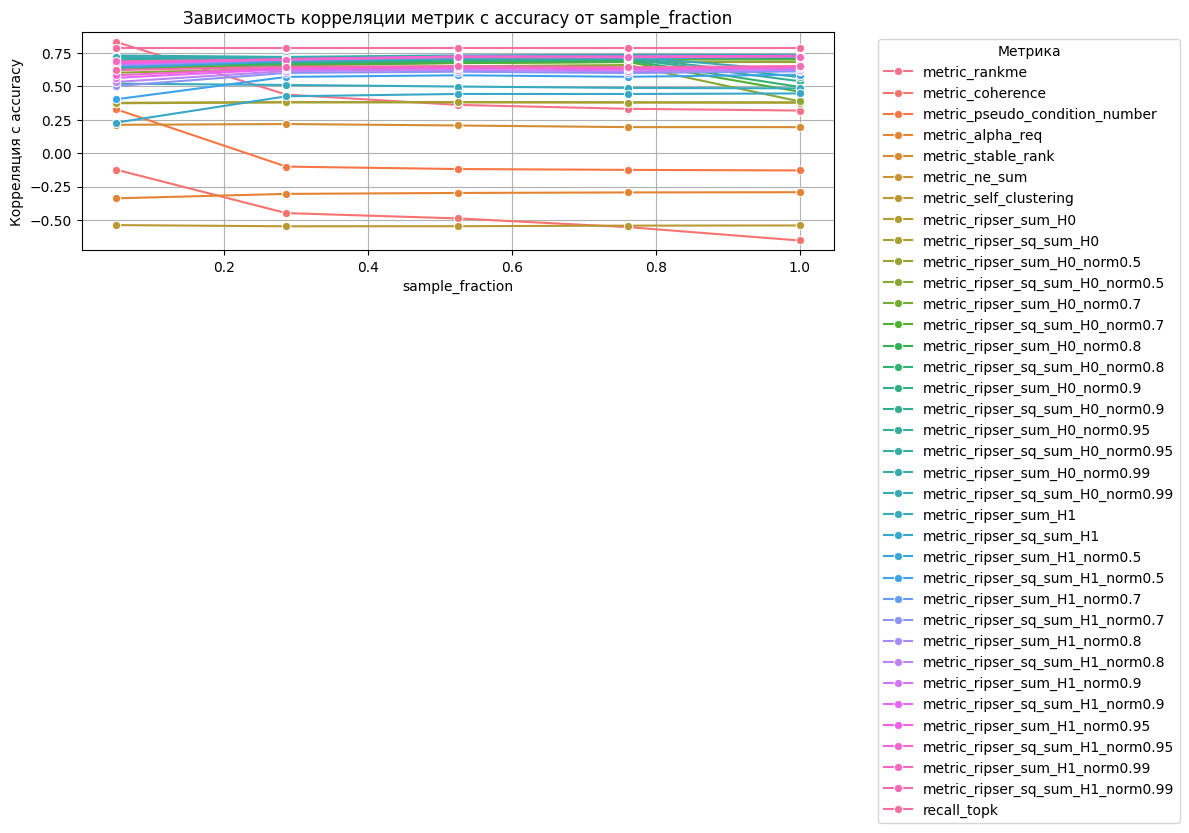

In [8]:
corr_df = pd.DataFrame(corr_records)

plt.figure(figsize=(12, 6))
sns.lineplot(data=corr_df, x="sample_fraction", y="correlation", hue="metric", marker="o")
plt.title("Зависимость корреляции метрик с accuracy от sample_fraction")
plt.xlabel("sample_fraction")
plt.ylabel("Корреляция с accuracy")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
plt.tight_layout()
plt.show()

In [9]:
print(corr_df)

     sample_fraction                            metric  correlation
0               0.05                     metric_rankme     0.831791
1               0.05                  metric_coherence    -0.123350
2               0.05    metric_pseudo_condition_number     0.328531
3               0.05                  metric_alpha_req    -0.338423
4               0.05                metric_stable_rank     0.211243
..               ...                               ...          ...
175             1.00     metric_ripser_sum_H1_norm0.95     0.726507
176             1.00  metric_ripser_sq_sum_H1_norm0.95     0.642789
177             1.00     metric_ripser_sum_H1_norm0.99     0.721906
178             1.00  metric_ripser_sq_sum_H1_norm0.99     0.650615
179             1.00                       recall_topk     0.788611

[180 rows x 3 columns]


In [10]:
mean_corr = corr_df[corr_df['sample_fraction'] > 0.0].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr

metric
recall_topk                         0.788611
metric_ripser_sum_H0_norm0.99       0.729435
metric_ripser_sum_H0_norm0.95       0.717494
metric_ripser_sum_H0_norm0.9        0.709012
metric_ripser_sum_H1_norm0.95       0.708819
metric_ripser_sum_H1_norm0.99       0.708346
metric_ripser_sum_H1_norm0.9        0.707622
metric_ripser_sum_H1_norm0.8        0.704466
metric_ripser_sum_H1_norm0.7        0.700950
metric_ripser_sum_H0_norm0.8        0.696489
metric_ripser_sq_sum_H0_norm0.99    0.695372
metric_ripser_sum_H1_norm0.5        0.692249
metric_ripser_sum_H0_norm0.7        0.685599
metric_ripser_sq_sum_H0_norm0.95    0.673550
metric_ripser_sum_H0_norm0.5        0.664926
metric_ripser_sq_sum_H0_norm0.9     0.658989
metric_ne_sum                       0.644188
metric_ripser_sq_sum_H1_norm0.99    0.641740
metric_ripser_sq_sum_H0_norm0.8     0.638041
metric_ripser_sq_sum_H1_norm0.95    0.627529
metric_ripser_sq_sum_H0_norm0.7     0.620177
metric_ripser_sq_sum_H1_norm0.9     0.616912
met

In [11]:
mean_corr = corr_df[corr_df['sample_fraction'] > 0.8].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr

metric
recall_topk                         0.788611
metric_ripser_sum_H0_norm0.99       0.734364
metric_ripser_sum_H1_norm0.9        0.726936
metric_ripser_sum_H1_norm0.95       0.726507
metric_ripser_sum_H1_norm0.8        0.725761
metric_ripser_sum_H0_norm0.95       0.725659
metric_ripser_sum_H1_norm0.7        0.723764
metric_ripser_sum_H1_norm0.99       0.721906
metric_ripser_sum_H0_norm0.9        0.718625
metric_ripser_sum_H1_norm0.5        0.717924
metric_ripser_sum_H0_norm0.8        0.707812
metric_ripser_sum_H0_norm0.7        0.698501
metric_ripser_sum_H0_norm0.5        0.680370
metric_ripser_sq_sum_H1_norm0.99    0.650615
metric_ne_sum                       0.643526
metric_ripser_sq_sum_H1_norm0.95    0.642789
metric_ripser_sq_sum_H1_norm0.9     0.635098
metric_ripser_sq_sum_H1_norm0.8     0.622354
metric_ripser_sq_sum_H0_norm0.99    0.612427
metric_ripser_sq_sum_H1_norm0.7     0.610723
metric_ripser_sq_sum_H1_norm0.5     0.585597
metric_ripser_sq_sum_H0_norm0.95    0.567124
met

In [12]:
mean_corr = corr_df[corr_df['sample_fraction'] < 0.5].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr

metric
recall_topk                         0.788611
metric_ripser_sum_H0_norm0.99       0.724085
metric_ripser_sq_sum_H0_norm0.99    0.712481
metric_ripser_sum_H0_norm0.95       0.706011
metric_ripser_sum_H0_norm0.9        0.695457
metric_ripser_sum_H1_norm0.99       0.692536
metric_ripser_sq_sum_H0_norm0.95    0.690282
metric_ripser_sum_H1_norm0.95       0.687356
metric_ripser_sum_H1_norm0.9        0.684247
metric_ripser_sum_H0_norm0.8        0.680655
metric_ripser_sum_H1_norm0.8        0.678872
metric_ripser_sq_sum_H0_norm0.9     0.677580
metric_ripser_sum_H1_norm0.7        0.673699
metric_ripser_sum_H0_norm0.7        0.667715
metric_ripser_sum_H1_norm0.5        0.661905
metric_ripser_sq_sum_H0_norm0.8     0.659956
metric_ne_sum                       0.650965
metric_ripser_sq_sum_H0_norm0.7     0.644625
metric_ripser_sum_H0_norm0.5        0.643894
metric_rankme                       0.634548
metric_ripser_sq_sum_H1_norm0.99    0.633094
metric_ripser_sq_sum_H0_norm0.5     0.615685
met

# Overall Spearmann Corr

In [13]:
from scipy.stats import spearmanr


spear_corr_records = []

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for metric in metric_columns:
        sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
            sub['roc_auc'], method='spearman'))
        if sub[metric].nunique() > 1 and sub['accuracy'].nunique() > 1:
            corr, _ = spearmanr(sub[metric], sub['roc_auc'])
            spear_corr_records.append({
                "sample_fraction": frac,
                "metric": metric,
                "correlation": corr #* sign
            })
            


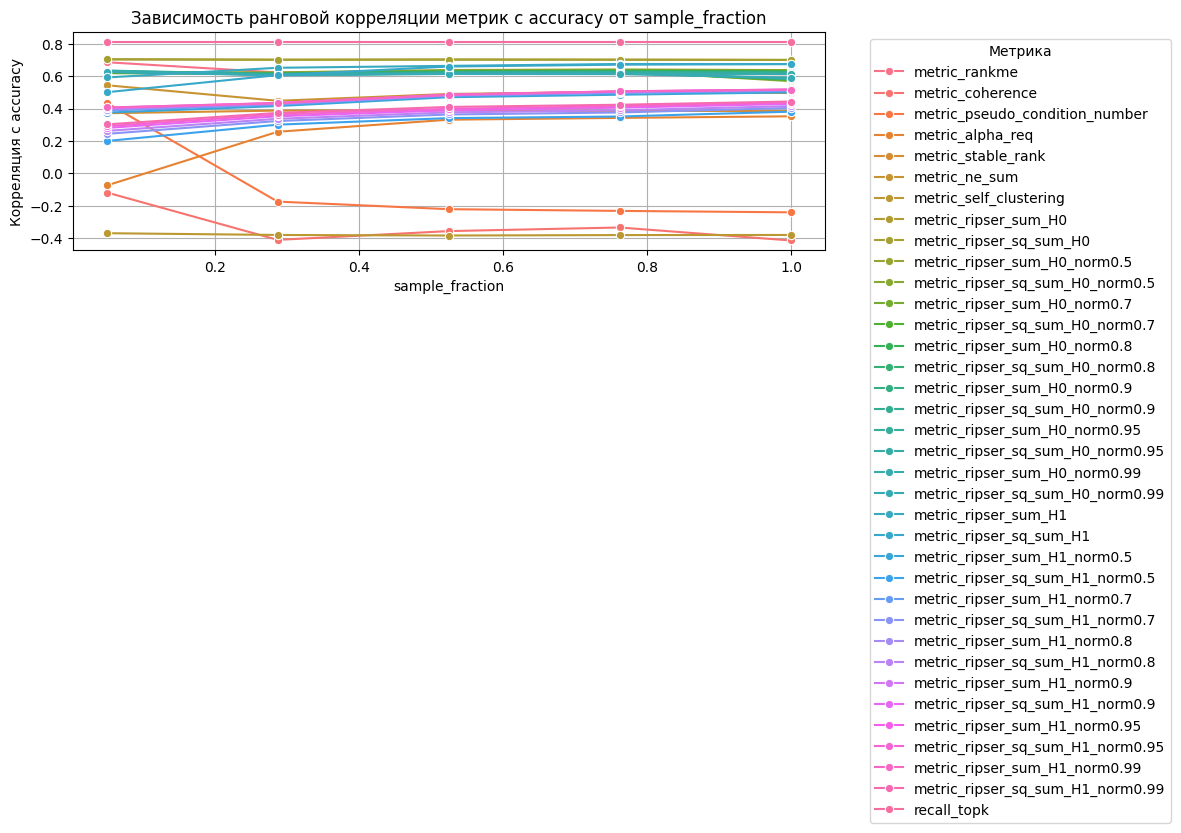

In [14]:
spear_corr_df = pd.DataFrame(spear_corr_records)

plt.figure(figsize=(12, 6))
sns.lineplot(data=spear_corr_df, x="sample_fraction", y="correlation", hue="metric", marker="o")
plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
plt.xlabel("sample_fraction")
plt.ylabel("Корреляция с accuracy")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
plt.tight_layout()
plt.show()

In [15]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] > 0.8].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'recall_topk': 0.8125743744680834,
 'metric_ripser_sum_H0': 0.7007014699768536,
 'metric_ripser_sq_sum_H0': 0.7005051942016206,
 'metric_ripser_sum_H1': 0.6752429091480918,
 'metric_ripser_sq_sum_H1': 0.6745789397847739,
 'metric_ripser_sum_H0_norm0.5': 0.6377196226422943,
 'metric_ripser_sum_H0_norm0.7': 0.6339047518311152,
 'metric_ripser_sum_H0_norm0.8': 0.6302484748515329,
 'metric_ripser_sum_H0_norm0.9': 0.6248029571020882,
 'metric_ripser_sum_H0_norm0.95': 0.6208450801325504,
 'metric_ripser_sum_H0_norm0.99': 0.6125925219798085,
 'metric_rankme': 0.6125486399216115,
 'metric_ripser_sq_sum_H0_norm0.99': 0.5912012679027819,
 'metric_ripser_sq_sum_H0_norm0.95': 0.5859515104220616,
 'metric_ripser_sq_sum_H0_norm0.9': 0.5830821583460267,
 'metric_ripser_sq_sum_H0_norm0.8': 0.580693849136469,
 'metric_ripser_sq_sum_H0_norm0.7': 0.5751213015392375,
 'metric_ripser_sq_sum_H0_norm0.5': 0.569388398058177,
 'metric_ripser_sum_H1_norm0.95': 0.5177524279948762,
 'metric_ripser_sum_H1_norm0.9

In [16]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] > 0.0].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'recall_topk': 0.8125743744680834,
 'metric_ripser_sum_H0': 0.7025172972306386,
 'metric_ripser_sq_sum_H0': 0.7021941363387635,
 'metric_ripser_sum_H1': 0.6517907020066976,
 'metric_ripser_sum_H0_norm0.5': 0.633080695130753,
 'metric_rankme': 0.6314857131868574,
 'metric_ripser_sum_H0_norm0.7': 0.6297995518171288,
 'metric_ripser_sum_H0_norm0.8': 0.6277173509002512,
 'metric_ripser_sum_H0_norm0.9': 0.6245443890579307,
 'metric_ripser_sum_H0_norm0.95': 0.6231186002973447,
 'metric_ripser_sq_sum_H1': 0.6226618942095715,
 'metric_ripser_sum_H0_norm0.99': 0.6161766506834495,
 'metric_ripser_sq_sum_H0_norm0.8': 0.612842395481147,
 'metric_ripser_sq_sum_H0_norm0.95': 0.6125928099169949,
 'metric_ripser_sq_sum_H0_norm0.5': 0.6124569006106666,
 'metric_ripser_sq_sum_H0_norm0.7': 0.6123941716201834,
 'metric_ripser_sq_sum_H0_norm0.9': 0.6121551930463258,
 'metric_ripser_sq_sum_H0_norm0.99': 0.6099380870258706,
 'metric_ne_sum': 0.496280444246636,
 'metric_ripser_sum_H1_norm0.95': 0.46997677907

In [17]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] < 0.4].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'recall_topk': 0.8125743744680834,
 'metric_ripser_sum_H0': 0.7033084574981461,
 'metric_ripser_sq_sum_H0': 0.7029217915096964,
 'metric_rankme': 0.6546815542520512,
 'metric_ripser_sum_H0_norm0.95': 0.6238730268350283,
 'metric_ripser_sum_H0_norm0.5': 0.623833261438121,
 'metric_ripser_sum_H0_norm0.8': 0.6226285349320866,
 'metric_ripser_sum_H0_norm0.7': 0.6222908940810234,
 'metric_ripser_sum_H1': 0.6221577672188139,
 'metric_ripser_sum_H0_norm0.9': 0.6220353894963592,
 'metric_ripser_sq_sum_H0_norm0.95': 0.6209353557172259,
 'metric_ripser_sq_sum_H0_norm0.9': 0.6185193352065662,
 'metric_ripser_sum_H0_norm0.99': 0.6175435149247794,
 'metric_ripser_sq_sum_H0_norm0.8': 0.6175312797010831,
 'metric_ripser_sq_sum_H0_norm0.7': 0.6167360318863868,
 'metric_ripser_sq_sum_H0_norm0.5': 0.616402651568888,
 'metric_ripser_sq_sum_H0_norm0.99': 0.6160014075598748,
 'metric_ripser_sq_sum_H1': 0.5538467379948762,
 'metric_ne_sum': 0.4959566849395417,
 'metric_ripser_sum_H1_norm0.95': 0.4199797330

# Correlation for best checkpoint choice

In [19]:
from scipy.stats import spearmanr


spear_corr_records = []
df_all['checkpoint'] = df_all.index.values
runs = df_all['checkpoint'].values
for i in range(df_all.shape[0]):
    runs[i] = runs[i][:-10]

df_all['runs'] = runs

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for metric in metric_columns:
        sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
            sub['roc_auc'], method='spearman'))
        for check, check_data in sub.groupby('runs'):        
            if check_data[metric].nunique() > 1 and check_data['accuracy'].nunique() > 1:
                corr, _ = spearmanr(check_data[metric], check_data['roc_auc'])
                spear_corr_records.append({
                    "sample_fraction": frac,
                    "metric": metric,
                    "correlation": sign * corr
                })
            


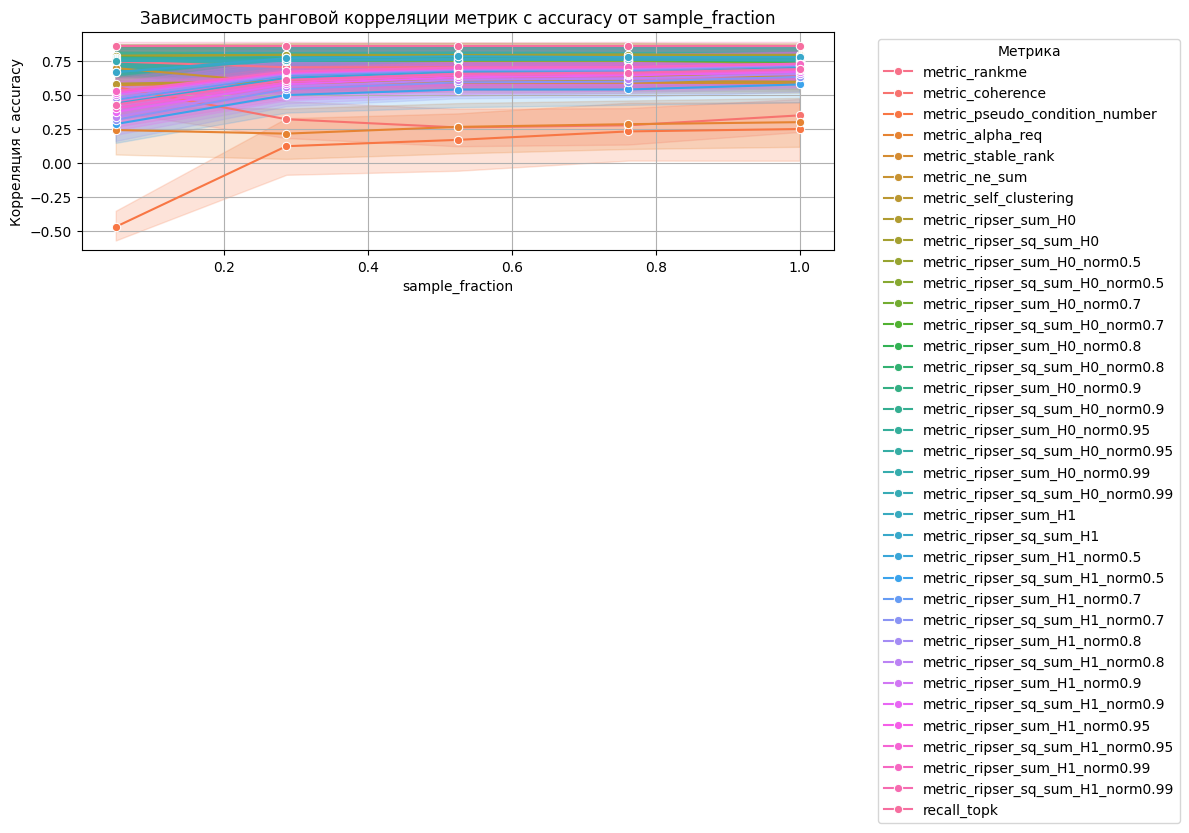

In [20]:
spear_corr_df = pd.DataFrame(spear_corr_records)

plt.figure(figsize=(12, 6))
sns.lineplot(data=spear_corr_df, x="sample_fraction", y="correlation", hue="metric", marker="o")
plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
plt.xlabel("sample_fraction")
plt.ylabel("Корреляция с accuracy")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
plt.tight_layout()
plt.show()

In [21]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] > 0.8].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'recall_topk': 0.8576161601503199,
 'metric_ripser_sum_H0': 0.7938895645541494,
 'metric_ripser_sq_sum_H0': 0.7838652340147735,
 'metric_ripser_sq_sum_H1': 0.7778830859326779,
 'metric_ripser_sum_H1': 0.7752016002660047,
 'metric_ripser_sum_H0_norm0.95': 0.7653834095842164,
 'metric_ripser_sum_H0_norm0.9': 0.7650811183107773,
 'metric_ripser_sum_H0_norm0.99': 0.7617267259404467,
 'metric_ripser_sum_H0_norm0.8': 0.76053055707855,
 'metric_ripser_sum_H0_norm0.7': 0.7567054944091317,
 'metric_ripser_sq_sum_H0_norm0.95': 0.7537533738274517,
 'metric_ripser_sq_sum_H0_norm0.99': 0.7534310054489557,
 'metric_ripser_sq_sum_H0_norm0.9': 0.7511765102245784,
 'metric_ripser_sum_H0_norm0.5': 0.7501889051573378,
 'metric_ripser_sq_sum_H0_norm0.8': 0.7449362190231081,
 'metric_ripser_sq_sum_H0_norm0.7': 0.7421763480029255,
 'metric_ripser_sq_sum_H0_norm0.5': 0.7338462414026526,
 'metric_ripser_sum_H1_norm0.95': 0.729132523556908,
 'metric_ripser_sum_H1_norm0.99': 0.72749321594846,
 'metric_ripser_s

In [22]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] > 0.0].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'recall_topk': 0.85761616015032,
 'metric_ripser_sum_H0': 0.7920719713153883,
 'metric_ripser_sq_sum_H0': 0.7897581400944231,
 'metric_ripser_sum_H0_norm0.95': 0.7680551758961754,
 'metric_ripser_sum_H0_norm0.9': 0.7678980005999921,
 'metric_ripser_sum_H0_norm0.8': 0.7656113526433019,
 'metric_ripser_sq_sum_H0_norm0.95': 0.7607809518783666,
 'metric_ripser_sq_sum_H0_norm0.9': 0.7605324217210095,
 'metric_ripser_sum_H0_norm0.7': 0.760026838551109,
 'metric_ripser_sum_H0_norm0.99': 0.7592969840348966,
 'metric_ripser_sq_sum_H0_norm0.8': 0.7564483034217038,
 'metric_ripser_sq_sum_H1': 0.7545984861802773,
 'metric_ripser_sum_H0_norm0.5': 0.7526081315245943,
 'metric_ripser_sq_sum_H0_norm0.99': 0.7525702329948096,
 'metric_ripser_sq_sum_H0_norm0.7': 0.7519589442797106,
 'metric_ripser_sq_sum_H0_norm0.5': 0.7467420338559774,
 'metric_ripser_sum_H1': 0.7448620412997429,
 'metric_rankme': 0.705961908423534,
 'metric_ripser_sum_H1_norm0.99': 0.665807373668663,
 'metric_ripser_sum_H1_norm0.95':

In [23]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] < 0.5].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'recall_topk': 0.8576161601503199,
 'metric_ripser_sum_H0': 0.7900758223703062,
 'metric_ripser_sq_sum_H0': 0.789426166673313,
 'metric_ripser_sum_H0_norm0.95': 0.7696151551014127,
 'metric_ripser_sum_H0_norm0.9': 0.7696084028270975,
 'metric_ripser_sum_H0_norm0.8': 0.7685715145525754,
 'metric_ripser_sq_sum_H0_norm0.9': 0.7640872177103342,
 'metric_ripser_sq_sum_H0_norm0.95': 0.7620723990026054,
 'metric_ripser_sum_H0_norm0.7': 0.761301273360961,
 'metric_ripser_sq_sum_H0_norm0.8': 0.7604882051541656,
 'metric_ripser_sum_H0_norm0.99': 0.7553957462445041,
 'metric_ripser_sum_H0_norm0.5': 0.7546492809337538,
 'metric_ripser_sq_sum_H0_norm0.7': 0.7527684675181668,
 'metric_ripser_sq_sum_H0_norm0.5': 0.7499484448107421,
 'metric_ripser_sq_sum_H0_norm0.99': 0.7482344360832777,
 'metric_rankme': 0.723312722465538,
 'metric_ripser_sq_sum_H1': 0.7176722220672179,
 'metric_ripser_sum_H1': 0.7102146460075802,
 'metric_ne_sum': 0.6405833664985574,
 'metric_ripser_sum_H1_norm0.99': 0.59835908329

# Linear correlation of epoch choice

In [24]:

corr_records = []
runs = df_all['checkpoint'].values
for i in range(df_all.shape[0]):
    runs[i] = runs[i][:-10]

df_all['runs'] = runs

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for metric in metric_columns:
        sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
            sub['roc_auc'], method='spearman'))
        for check, check_data in sub.groupby('runs'):        
            if check_data[metric].nunique() > 1 and check_data['accuracy'].nunique() > 1:
                corr = check_data[metric].corr(check_data['roc_auc'])
                corr_records.append({
                    "sample_fraction": frac,
                    "metric": metric,
                    "correlation": sign * corr
                })
     

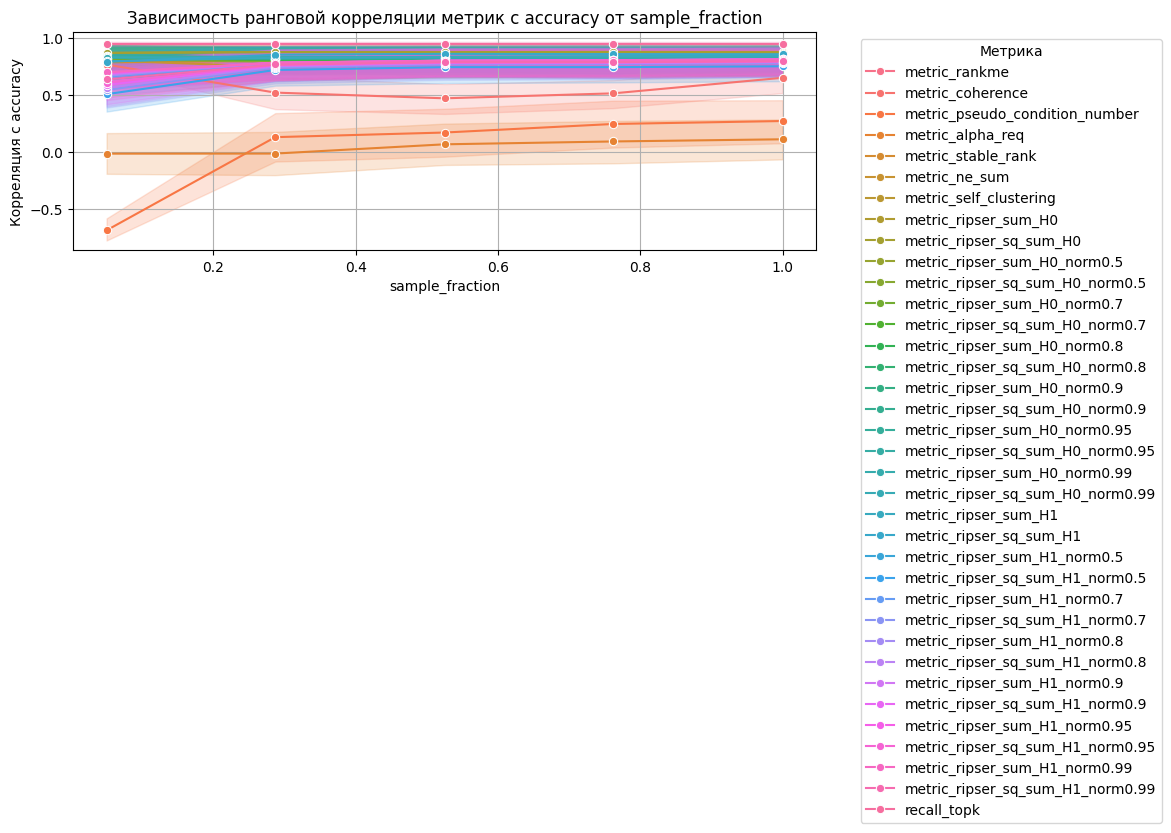

In [25]:
corr_df = pd.DataFrame(corr_records)

plt.figure(figsize=(12, 6))
sns.lineplot(data=corr_df, x="sample_fraction", y="correlation", hue="metric", marker="o")
plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
plt.xlabel("sample_fraction")
plt.ylabel("Корреляция с accuracy")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
plt.tight_layout()
plt.show()

In [26]:
mean_corr = corr_df[corr_df['sample_fraction'] > 0.8].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr

metric
recall_topk                         0.950968
metric_ripser_sum_H0                0.878349
metric_ripser_sq_sum_H0             0.870481
metric_ripser_sq_sum_H1             0.858332
metric_ripser_sum_H1                0.844944
metric_ripser_sq_sum_H0_norm0.99    0.840355
metric_ripser_sq_sum_H0_norm0.95    0.834408
metric_ripser_sum_H0_norm0.99       0.833697
metric_ripser_sum_H0_norm0.95       0.829826
metric_ripser_sq_sum_H0_norm0.9     0.829809
metric_ripser_sum_H0_norm0.9        0.826757
metric_ripser_sq_sum_H0_norm0.8     0.822660
metric_ripser_sum_H0_norm0.8        0.822237
metric_ripser_sum_H0_norm0.7        0.817763
metric_ripser_sq_sum_H0_norm0.7     0.815652
metric_self_clustering              0.814170
metric_ripser_sum_H1_norm0.9        0.813923
metric_ripser_sum_H1_norm0.95       0.813748
metric_ripser_sum_H1_norm0.8        0.813274
metric_ripser_sum_H1_norm0.7        0.811874
metric_ripser_sum_H1_norm0.99       0.811289
metric_ripser_sum_H1_norm0.5        0.806745
met

In [27]:
mean_corr = corr_df[corr_df['sample_fraction'] < 0.4].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr

metric
recall_topk                         0.950968
metric_ripser_sum_H0                0.874360
metric_ripser_sq_sum_H0             0.872954
metric_ripser_sum_H0_norm0.95       0.837188
metric_ripser_sum_H0_norm0.9        0.834485
metric_ripser_sum_H0_norm0.99       0.833571
metric_ripser_sum_H0_norm0.8        0.829959
metric_ripser_sq_sum_H0_norm0.95    0.829320
metric_ripser_sq_sum_H0_norm0.99    0.826337
metric_ripser_sq_sum_H0_norm0.9     0.826020
metric_ripser_sum_H0_norm0.7        0.825117
metric_ripser_sq_sum_H1             0.822743
metric_ripser_sq_sum_H0_norm0.8     0.820425
metric_rankme                       0.815296
metric_ripser_sq_sum_H0_norm0.7     0.814686
metric_ripser_sum_H0_norm0.5        0.814485
metric_ripser_sum_H1                0.811799
metric_self_clustering              0.809998
metric_ripser_sq_sum_H0_norm0.5     0.802312
metric_stable_rank                  0.792977
metric_ne_sum                       0.775465
metric_ripser_sum_H1_norm0.99       0.741598
met

# Score of best epoch

In [28]:
corr_records = []
runs = df_all['checkpoint'].values
for i in range(df_all.shape[0]):
    runs[i] = runs[i][:-10]

df_all['runs'] = runs

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for metric in metric_columns:
        sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
            sub['roc_auc'], method='spearman'))
        for check, check_data in sub.groupby('runs'):
            if check_data[metric].nunique() > 1 and check_data['accuracy'].nunique() > 1:
                pick = check_data['roc_auc'].values[
                    np.argmax(sign * check_data[metric].values)]
                corr_records.append({
                    "sample_fraction": frac,
                    "metric": metric,
                    "auc": pick
                })

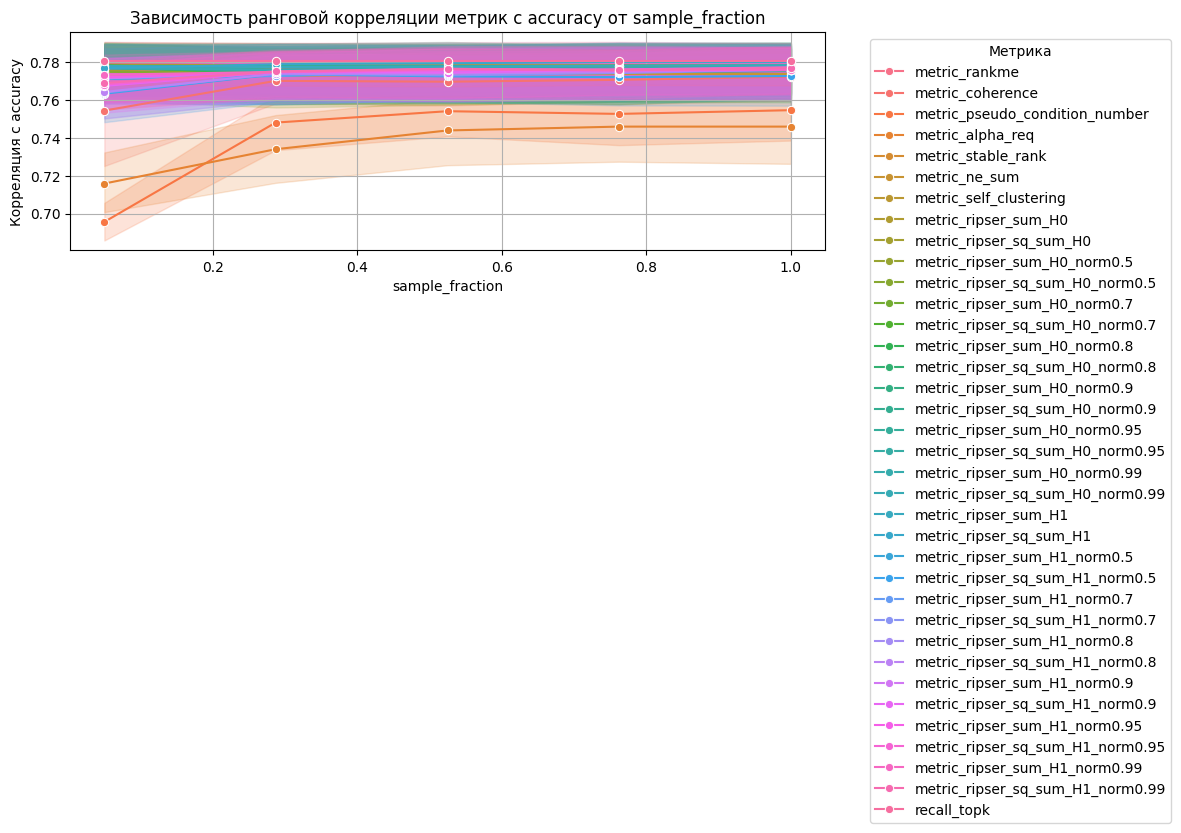

In [29]:
corr_df = pd.DataFrame(corr_records)

plt.figure(figsize=(12, 6))
sns.lineplot(data=corr_df, x="sample_fraction", y="auc", hue="metric", marker="o")
plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
plt.xlabel("sample_fraction")
plt.ylabel("Корреляция с accuracy")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
plt.tight_layout()
plt.show()

In [30]:
corr_df = pd.DataFrame(corr_records)
mean_corr = corr_df[corr_df['sample_fraction'] > 0.0].groupby("metric")["auc"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'recall_topk': 0.7803282051282051,
 'metric_ripser_sq_sum_H1': 0.7789882051282052,
 'metric_stable_rank': 0.7783078947368421,
 'metric_self_clustering': 0.7781968421052632,
 'metric_ripser_sum_H0': 0.7780215384615385,
 'metric_ripser_sq_sum_H0': 0.777977435897436,
 'metric_ripser_sum_H0_norm0.95': 0.7778323076923077,
 'metric_ripser_sum_H1': 0.7778292307692308,
 'metric_ripser_sum_H0_norm0.9': 0.7773128205128205,
 'metric_rankme': 0.7771815384615385,
 'metric_ripser_sum_H0_norm0.99': 0.7770179487179487,
 'metric_ripser_sq_sum_H0_norm0.95': 0.7766210256410256,
 'metric_ripser_sq_sum_H0_norm0.99': 0.7765758974358974,
 'metric_ripser_sum_H0_norm0.8': 0.7764353846153846,
 'metric_ripser_sq_sum_H0_norm0.9': 0.7758507692307692,
 'metric_ripser_sum_H0_norm0.7': 0.7754128205128206,
 'metric_ripser_sum_H1_norm0.99': 0.7752671794871795,
 'metric_ripser_sq_sum_H0_norm0.7': 0.7752302564102564,
 'metric_ripser_sq_sum_H0_norm0.8': 0.7752087179487179,
 'metric_ripser_sum_H0_norm0.5': 0.7749379487179

In [31]:
mean_corr = corr_df[corr_df['sample_fraction'] > 0.8].groupby("metric")["auc"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'recall_topk': 0.7803282051282051,
 'metric_ripser_sq_sum_H1': 0.7799923076923077,
 'metric_ripser_sum_H1': 0.7783461538461538,
 'metric_self_clustering': 0.7781894736842105,
 'metric_stable_rank': 0.7781894736842105,
 'metric_ripser_sum_H0': 0.7780051282051282,
 'metric_ripser_sum_H0_norm0.95': 0.7779820512820513,
 'metric_ripser_sq_sum_H0': 0.7779256410256411,
 'metric_ripser_sq_sum_H0_norm0.95': 0.7775230769230769,
 'metric_ripser_sum_H0_norm0.99': 0.7775025641025641,
 'metric_ripser_sq_sum_H0_norm0.99': 0.777448717948718,
 'metric_ripser_sq_sum_H1_norm0.95': 0.7772230769230769,
 'metric_rankme': 0.7770538461538461,
 'metric_ripser_sq_sum_H1_norm0.99': 0.7769538461538461,
 'metric_ripser_sq_sum_H1_norm0.9': 0.776448717948718,
 'metric_ripser_sum_H0_norm0.9': 0.7764205128205128,
 'metric_ripser_sq_sum_H1_norm0.8': 0.7760769230769231,
 'metric_ripser_sum_H1_norm0.99': 0.7760025641025641,
 'metric_ripser_sum_H0_norm0.8': 0.7759307692307692,
 'metric_ripser_sum_H1_norm0.5': 0.775917948

In [32]:
mean_corr = corr_df[corr_df['sample_fraction'] < 0.4].groupby("metric")["auc"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'recall_topk': 0.7803282051282051,
 'metric_stable_rank': 0.7784907894736842,
 'metric_self_clustering': 0.7782131578947368,
 'metric_ripser_sq_sum_H0': 0.7780641025641025,
 'metric_ripser_sum_H0': 0.7780461538461539,
 'metric_ripser_sum_H0_norm0.9': 0.7778987179487179,
 'metric_ripser_sq_sum_H1': 0.7777717948717949,
 'metric_ripser_sum_H1': 0.777626923076923,
 'metric_ripser_sum_H0_norm0.95': 0.7776,
 'metric_rankme': 0.7772935897435898,
 'metric_ripser_sum_H0_norm0.8': 0.7771,
 'metric_ripser_sum_H0_norm0.99': 0.7768576923076923,
 'metric_ripser_sq_sum_H0_norm0.95': 0.7763358974358975,
 'metric_ripser_sq_sum_H0_norm0.99': 0.7762820512820513,
 'metric_ripser_sq_sum_H0_norm0.9': 0.7761769230769231,
 'metric_ripser_sum_H0_norm0.7': 0.7757910256410256,
 'metric_ripser_sq_sum_H0_norm0.8': 0.7756871794871795,
 'metric_ripser_sq_sum_H0_norm0.7': 0.7756653846153846,
 'metric_ripser_sum_H0_norm0.5': 0.7748628205128205,
 'metric_ripser_sq_sum_H0_norm0.5': 0.7745423076923077,
 'metric_ne_sum':

In [33]:
from collections import defaultdict
comb_w = defaultdict(dict)
comb_prod = defaultdict(dict)

for metric in metric_columns:
    for i in range(mean_corr.shape[0]):
        if metric in mean_corr.index.values[i]:
            if 'prod' in mean_corr.index.values[i]:
                comb_prod[metric][mean_corr.index.values[i]] = mean_corr.values[i]
            elif 'weighted' in mean_corr.index.values[i]:
                comb_w[metric][mean_corr.index.values[i]] = mean_corr.values[i]



In [34]:
for metric in metric_columns:
    comb_prod[metric] = pd.Series(comb_prod[metric])
    print (metric, comb_prod[metric].mean())
    comb_w[metric] = pd.Series(comb_w[metric])
    print (metric, comb_w[metric].mean())

metric_rankme nan
metric_rankme nan
metric_coherence nan
metric_coherence nan
metric_pseudo_condition_number nan
metric_pseudo_condition_number nan
metric_alpha_req nan
metric_alpha_req nan
metric_stable_rank nan
metric_stable_rank nan
metric_ne_sum nan
metric_ne_sum nan
metric_self_clustering nan
metric_self_clustering nan
metric_ripser_sum_H0 nan
metric_ripser_sum_H0 nan
metric_ripser_sq_sum_H0 nan
metric_ripser_sq_sum_H0 nan
metric_ripser_sum_H0_norm0.5 nan
metric_ripser_sum_H0_norm0.5 nan
metric_ripser_sq_sum_H0_norm0.5 nan
metric_ripser_sq_sum_H0_norm0.5 nan
metric_ripser_sum_H0_norm0.7 nan
metric_ripser_sum_H0_norm0.7 nan
metric_ripser_sq_sum_H0_norm0.7 nan
metric_ripser_sq_sum_H0_norm0.7 nan
metric_ripser_sum_H0_norm0.8 nan
metric_ripser_sum_H0_norm0.8 nan
metric_ripser_sq_sum_H0_norm0.8 nan
metric_ripser_sq_sum_H0_norm0.8 nan
metric_ripser_sum_H0_norm0.9 nan
metric_ripser_sum_H0_norm0.9 nan
metric_ripser_sq_sum_H0_norm0.9 nan
metric_ripser_sq_sum_H0_norm0.9 nan
metric_ripser_su

# Corr of best hyperparam by metric

In [34]:
print(list(df_all.columns))

['batch_size', 'learning_rate', 'split_count', 'cnt_min', 'cnt_max', 'embedding_dim', 'category_embedding_dim', 'hidden_size', 'small_group_in', 'trans_date_in', 'num_epochs', 'loss', 'rnn_encoder_type', 'epoch_num', 'early_stop_epoch', 'recall_topk', 'metric_rankme', 'metric_coherence', 'metric_pseudo_condition_number', 'metric_alpha_req', 'metric_stable_rank', 'metric_ne_sum', 'metric_self_clustering', 'metric_ripser_sum_H0', 'metric_ripser_sq_sum_H0', 'metric_ripser_sum_H0_norm0.5', 'metric_ripser_sq_sum_H0_norm0.5', 'metric_ripser_sum_H0_norm0.7', 'metric_ripser_sq_sum_H0_norm0.7', 'metric_ripser_sum_H0_norm0.8', 'metric_ripser_sq_sum_H0_norm0.8', 'metric_ripser_sum_H0_norm0.9', 'metric_ripser_sq_sum_H0_norm0.9', 'metric_ripser_sum_H0_norm0.95', 'metric_ripser_sq_sum_H0_norm0.95', 'metric_ripser_sum_H0_norm0.99', 'metric_ripser_sq_sum_H0_norm0.99', 'metric_ripser_sum_H1', 'metric_ripser_sq_sum_H1', 'metric_ripser_sum_H1_norm0.5', 'metric_ripser_sq_sum_H1_norm0.5', 'metric_ripser_su

In [35]:
from collections import defaultdict
params_cols=['batch_size', 
             'learning_rate', 
             'split_count',
             'cnt_min', 'cnt_max', 'embedding_dim', 
             'category_embedding_dim', 
             'hidden_size', 
             'loss', 
             'rnn_encoder_type']

corr_records = defaultdict(list)
runs = df_all['checkpoint'].values
for i in range(df_all.shape[0]):
    runs[i] = runs[i][:-10]

df_all['runs'] = runs

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for param in params_cols:
        curr_params = [p for p in params_cols if p != param]
        combined = "_".join(curr_params)
        sub[combined] = sub[curr_params].astype(str).sum(axis=1)
        for metric in metric_columns:
            sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
                sub['roc_auc'], method='spearman'))
            for check, check_data in sub.groupby(combined):   
                if check_data[param].nunique() <= 1:
                    continue
                if check_data[metric].nunique() > 1 and check_data['accuracy'].nunique()> 1:
                    corr = check_data[metric].corr(
                        check_data['roc_auc'], method='spearman')
                    corr_records[param].append({
                        "sample_fraction": frac,
                        "metric": metric,
                        "corr": sign * corr
                    })

/tmp/ipykernel_1644769/1662839960.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub[combined] = sub[curr_params].astype(str).sum(axis=1)
/tmp/ipykernel_1644769/1662839960.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub[combined] = sub[curr_params].astype(str).sum(axis=1)
/tmp/ipykernel_1644769/1662839960.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentati

batch_size


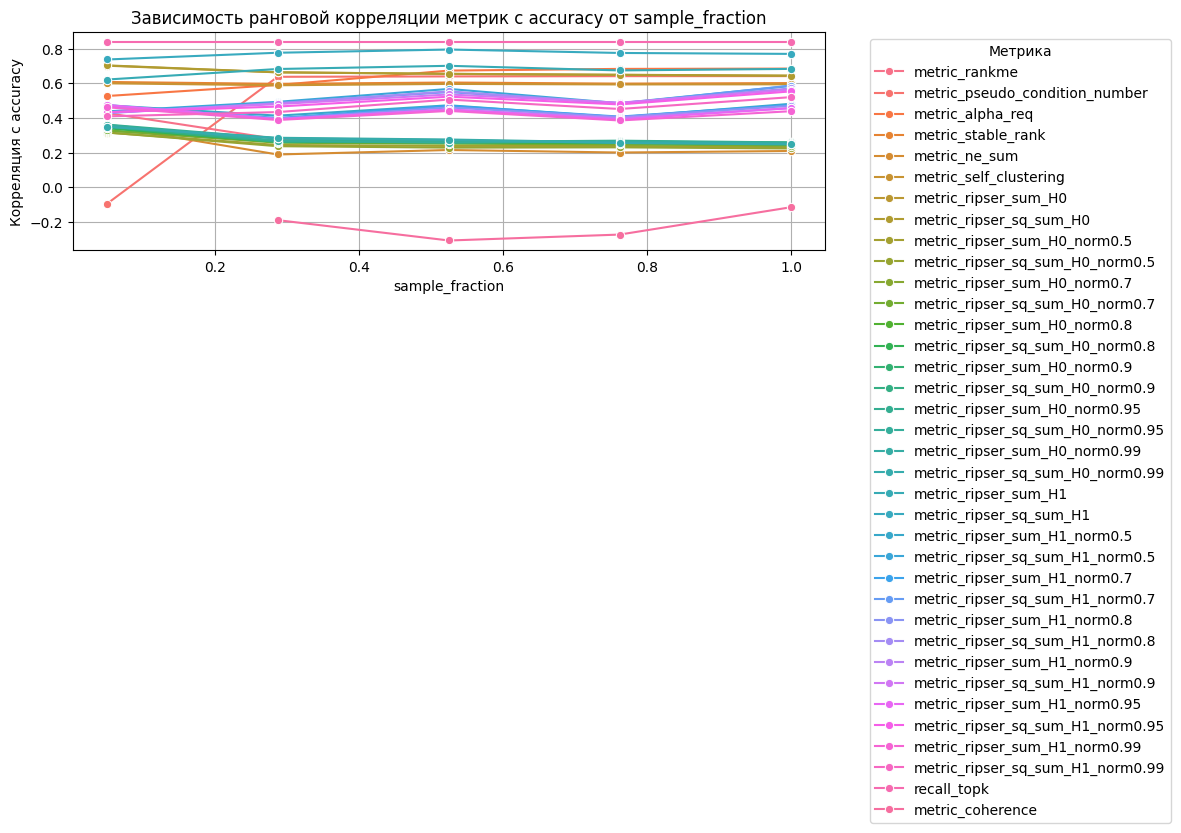

learning_rate


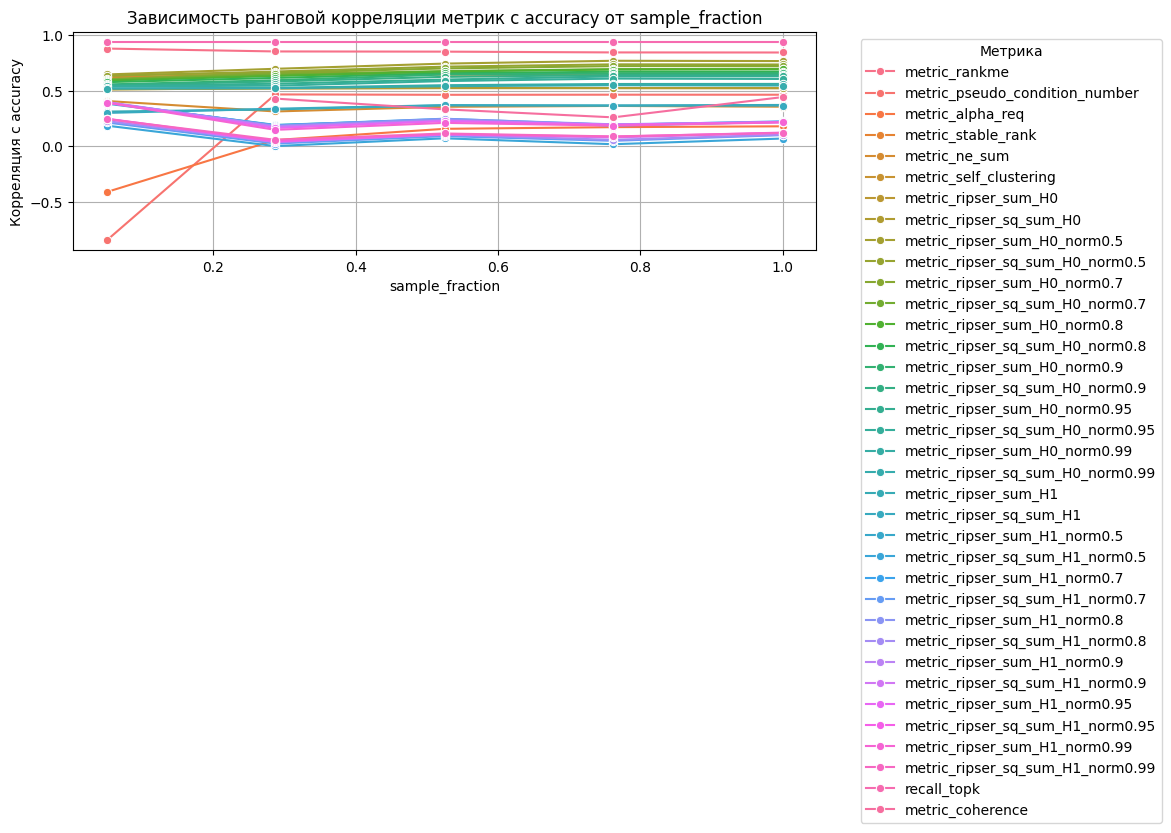

split_count


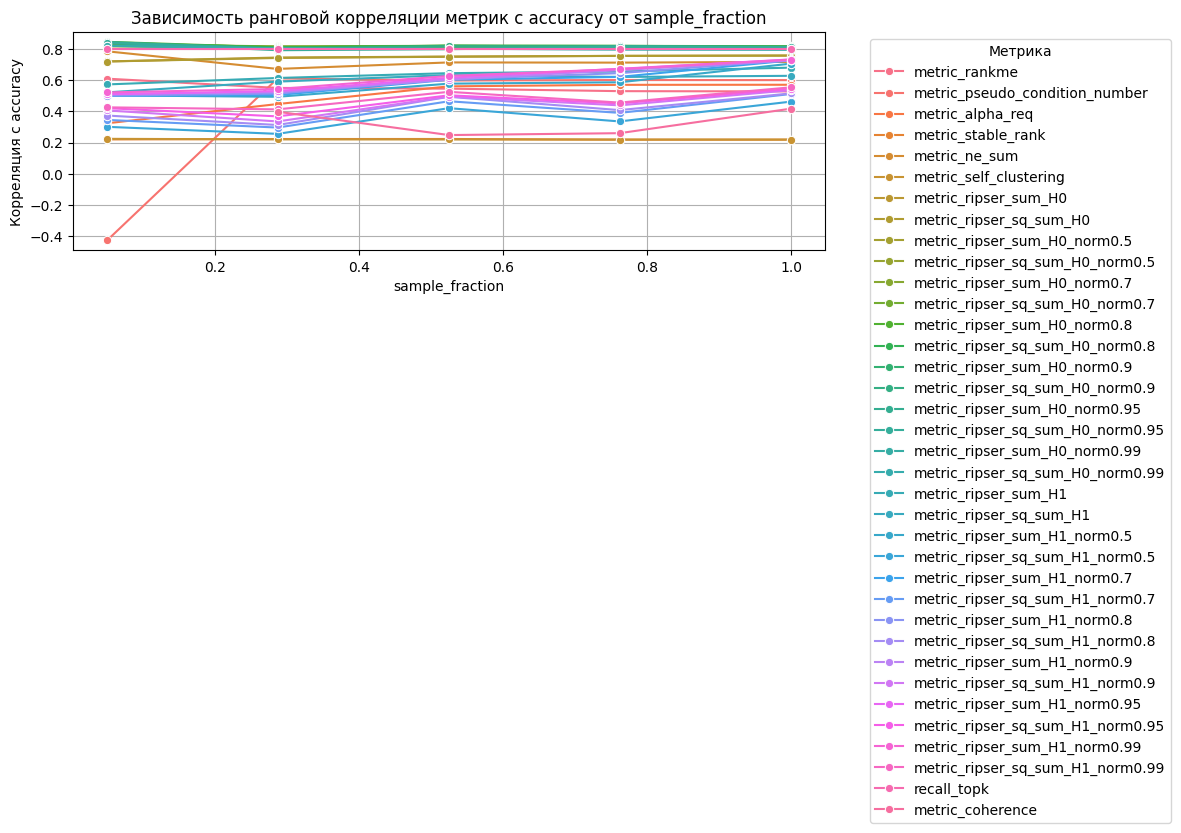

cnt_min


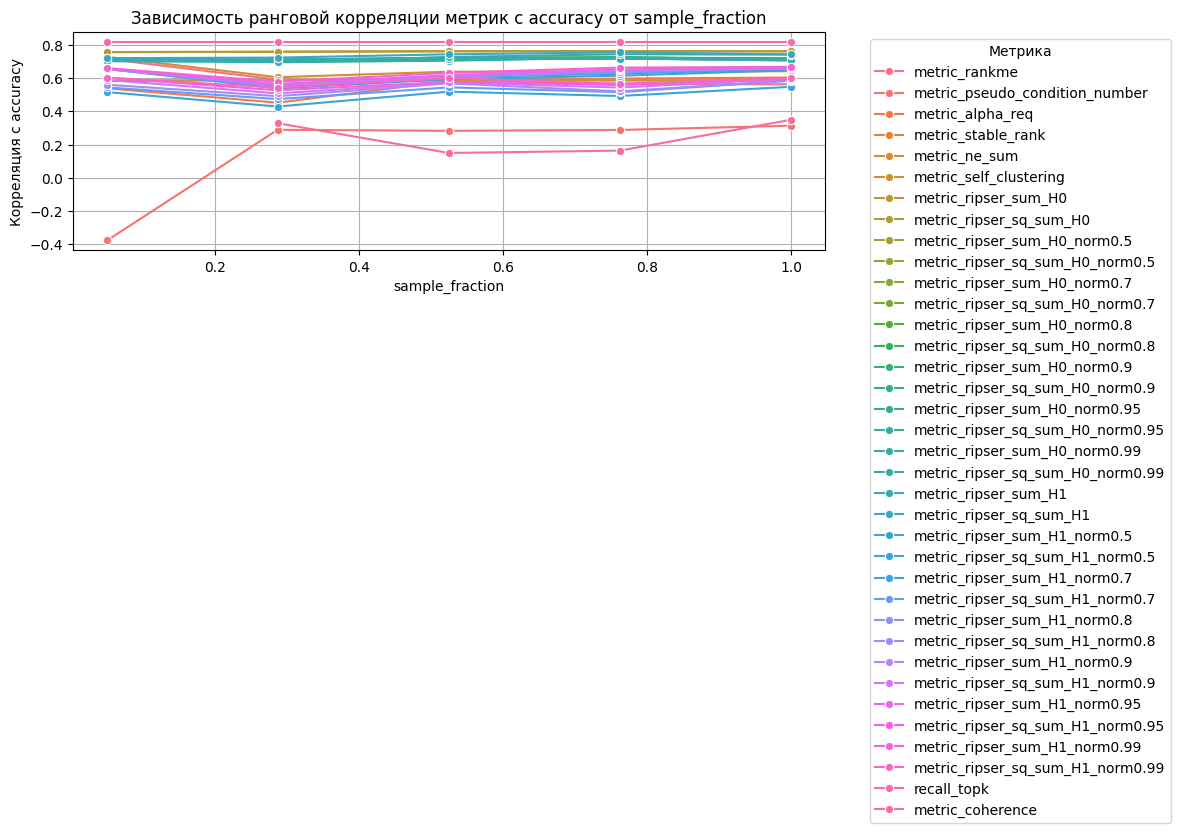

cnt_max


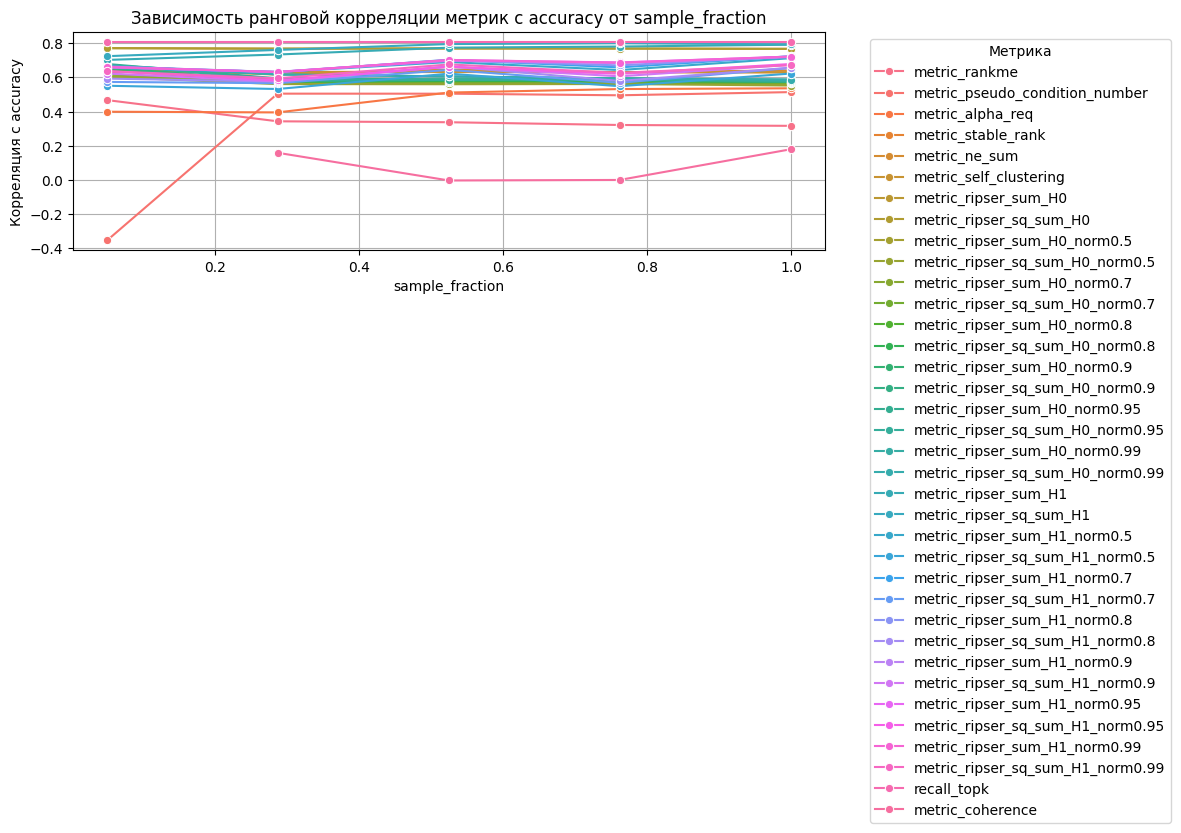

embedding_dim


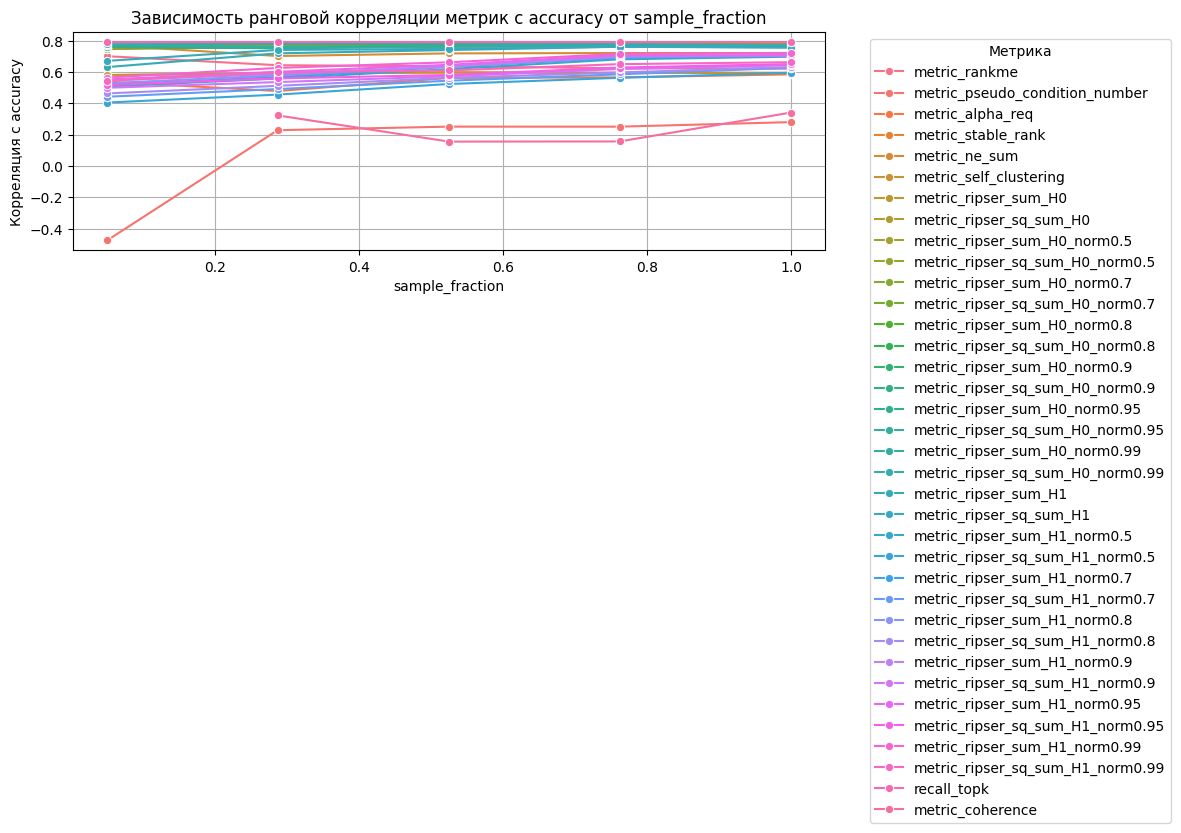

category_embedding_dim


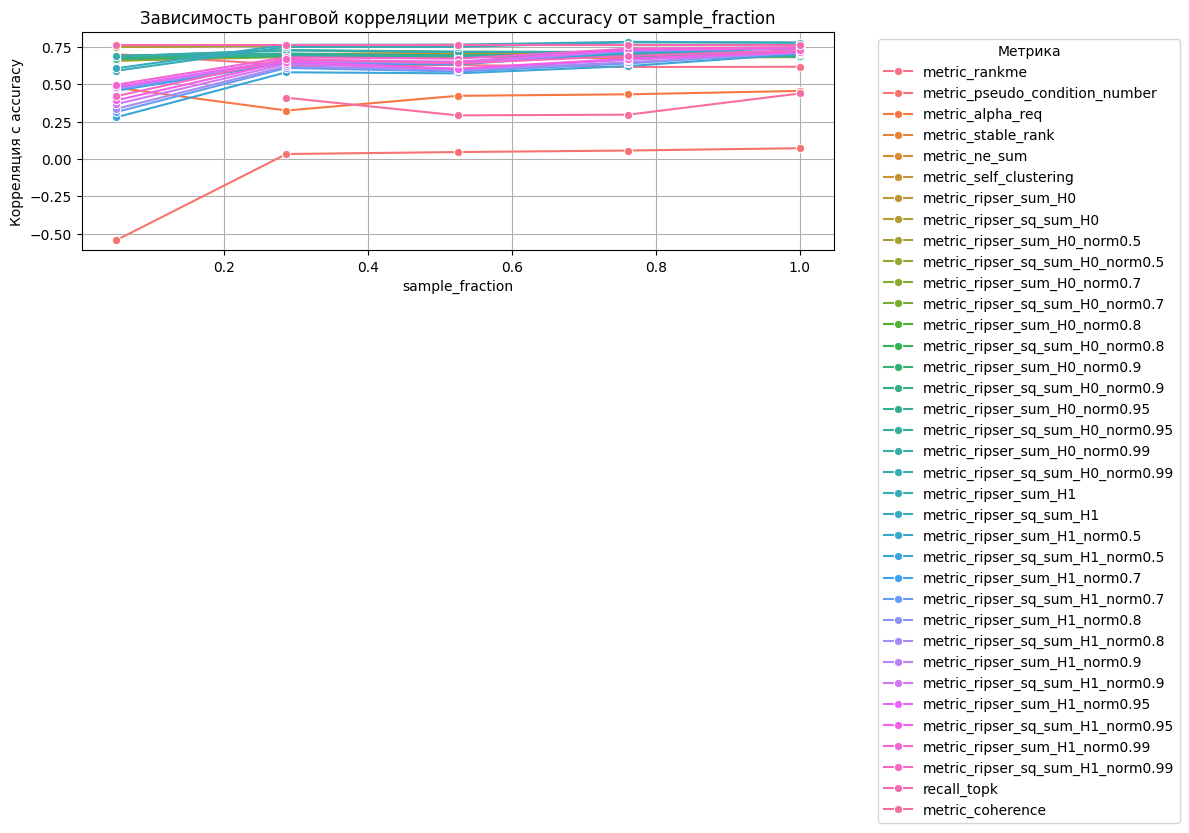

hidden_size


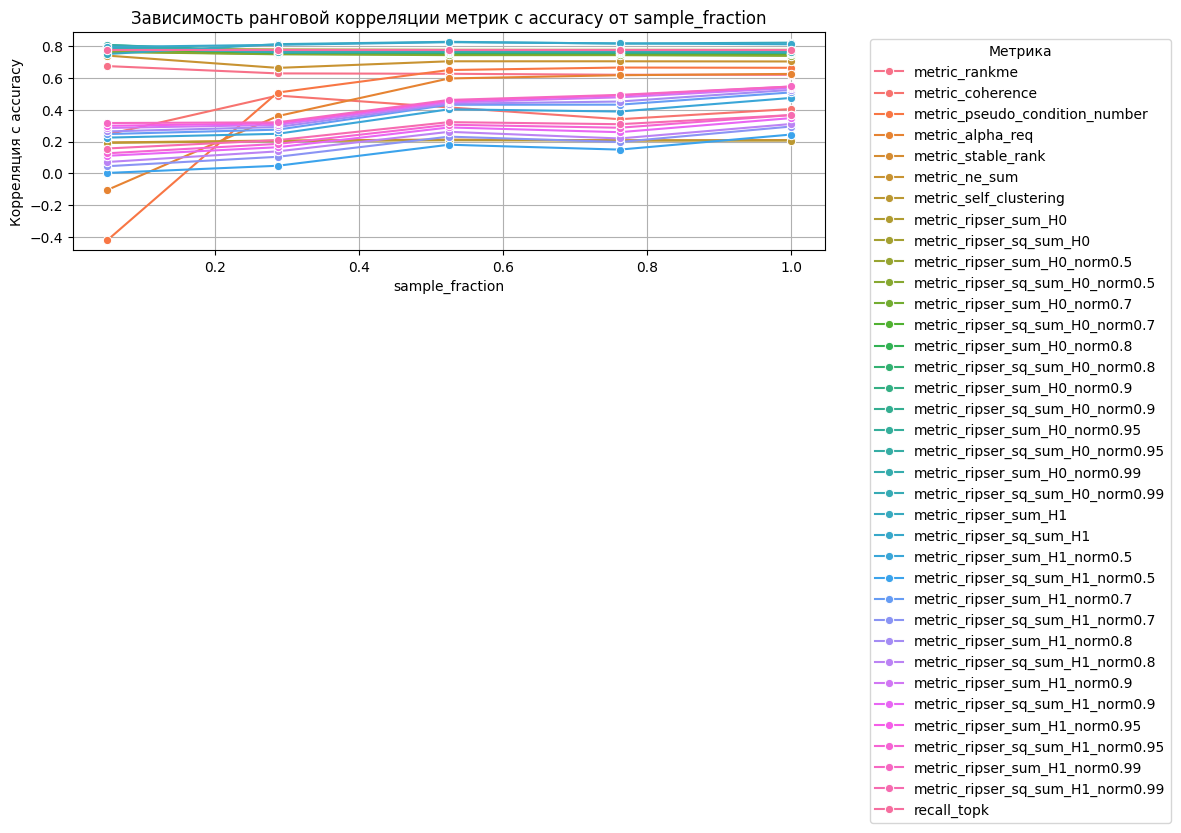

loss


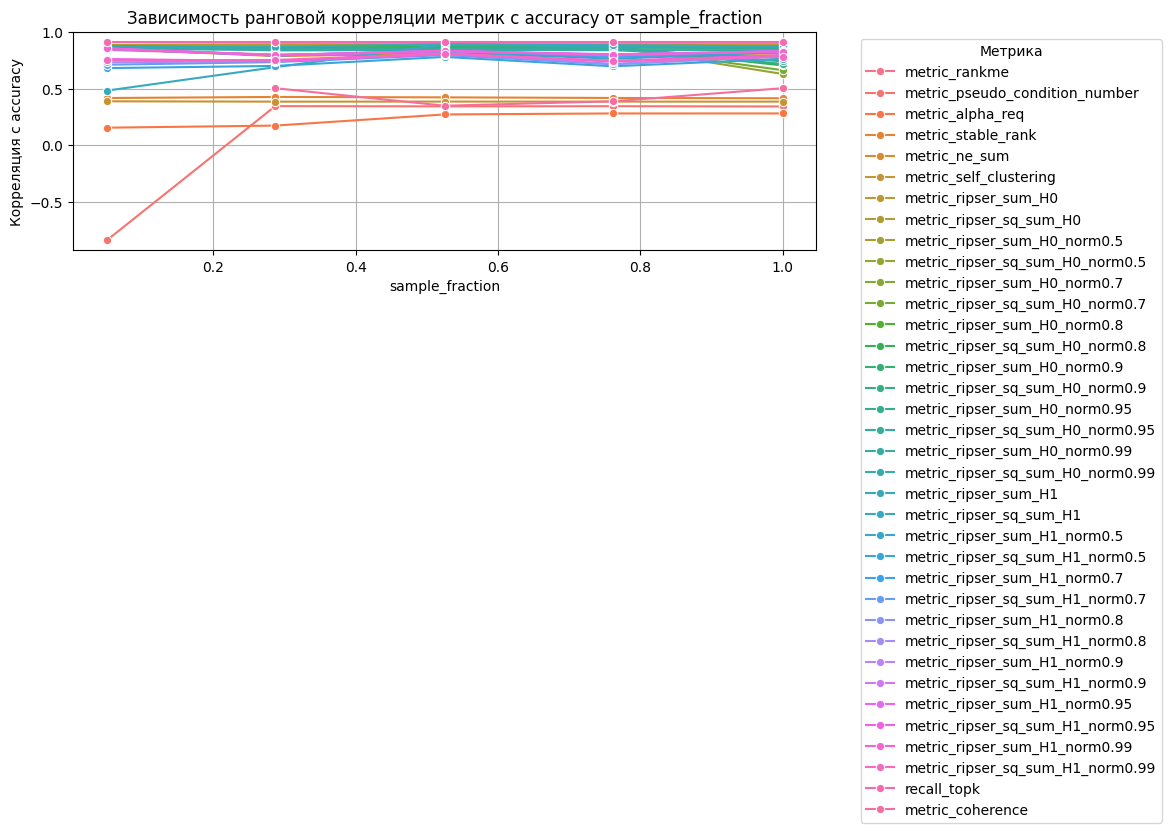

rnn_encoder_type


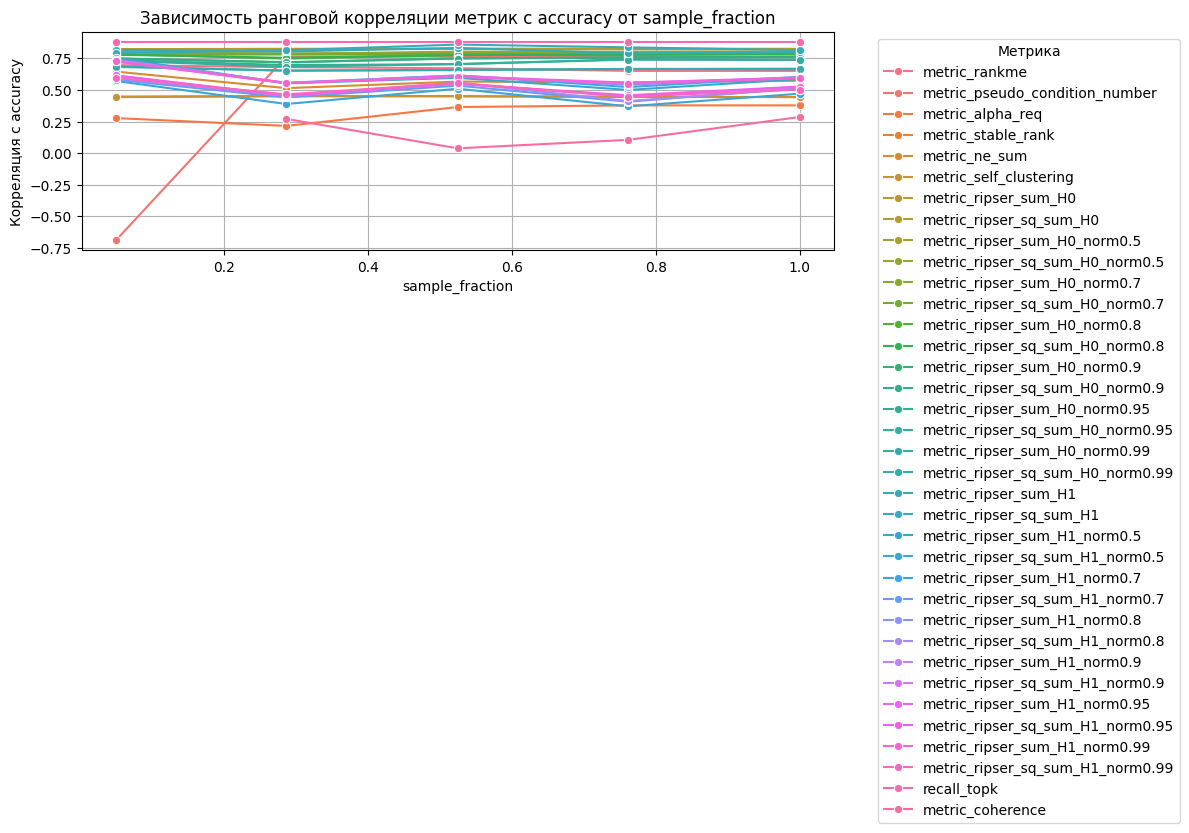

In [36]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    print(param)
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=corr_df, x="sample_fraction", y="corr", hue="metric", marker="o")
    plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
    plt.xlabel("sample_fraction")
    plt.ylabel("Корреляция с accuracy")
    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
    plt.tight_layout()
    plt.show()

In [37]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    print(param)
    print(corr_df)
    if (corr_df.shape[0]):
        mean_corr = corr_df[corr_df['sample_fraction'] < 0.5].groupby("metric")["corr"].mean().sort_values(ascending=False)
        print(mean_corr)

batch_size
     sample_fraction                            metric      corr
0               0.05                     metric_rankme  0.428666
1               0.05    metric_pseudo_condition_number -0.094451
2               0.05                  metric_alpha_req  0.527005
3               0.05                metric_stable_rank  0.608098
4               0.05                     metric_ne_sum  0.353785
..               ...                               ...       ...
174             1.00     metric_ripser_sum_H1_norm0.95  0.457266
175             1.00  metric_ripser_sq_sum_H1_norm0.95  0.553716
176             1.00     metric_ripser_sum_H1_norm0.99  0.439382
177             1.00  metric_ripser_sq_sum_H1_norm0.99  0.520469
178             1.00                       recall_topk  0.839579

[179 rows x 3 columns]
metric
recall_topk                         0.839579
metric_ripser_sq_sum_H1             0.757105
metric_ripser_sq_sum_H0             0.683788
metric_ripser_sum_H0                0.68262

# Score of best hyperparams by metric

In [39]:
from collections import defaultdict
params_cols=['batch_size', 
             'learning_rate', 
             'split_count',
             'cnt_min', 'cnt_max', 'embedding_dim', 
             'category_embedding_dim', 
             'hidden_size', 
             'loss', 
             'rnn_encoder_type']

corr_records = defaultdict(list)
runs = df_all['checkpoint'].values
for i in range(df_all.shape[0]):
    runs[i] = runs[i][:-10]

df_all['runs'] = runs

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for param in params_cols:
        curr_params = [p for p in params_cols if p != param]
        combined = "_".join(curr_params)
        sub[combined] = sub[curr_params].astype(str).sum(axis=1)
        for metric in metric_columns:
            sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
                sub['roc_auc'], method='spearman'))
            for check, check_data in sub.groupby(combined):   
                if check_data[param].nunique() <= 1:
                    continue
                if check_data[metric].nunique() > 1 and check_data['accuracy'].nunique() > 1:
                    
                    pick = check_data['roc_auc'].values[
                        np.argmax(sign * check_data[metric].values)]
                    corr_records[param].append({
                        "sample_fraction": frac,
                        "metric": metric,
                        "auc": pick
                    })

/tmp/ipykernel_1644769/2856340913.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub[combined] = sub[curr_params].astype(str).sum(axis=1)
/tmp/ipykernel_1644769/2856340913.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub[combined] = sub[curr_params].astype(str).sum(axis=1)
/tmp/ipykernel_1644769/2856340913.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentati

batch_size


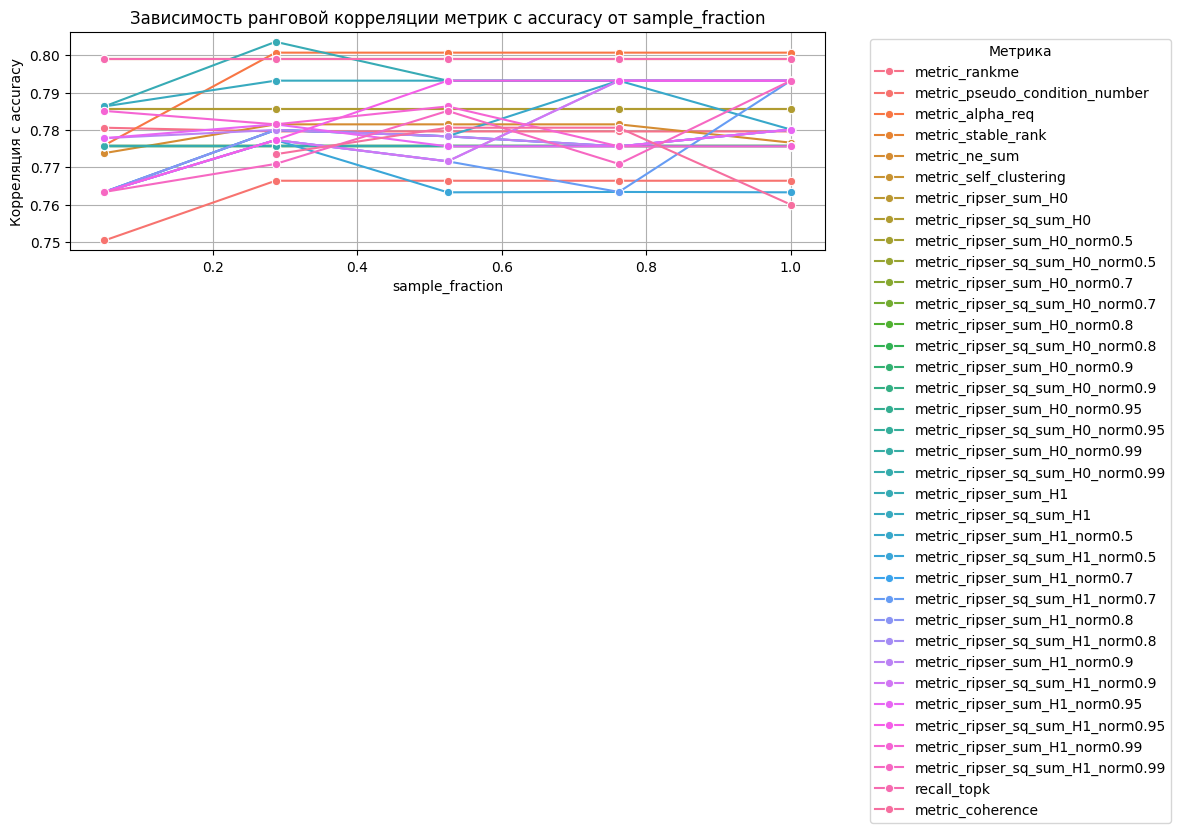

learning_rate


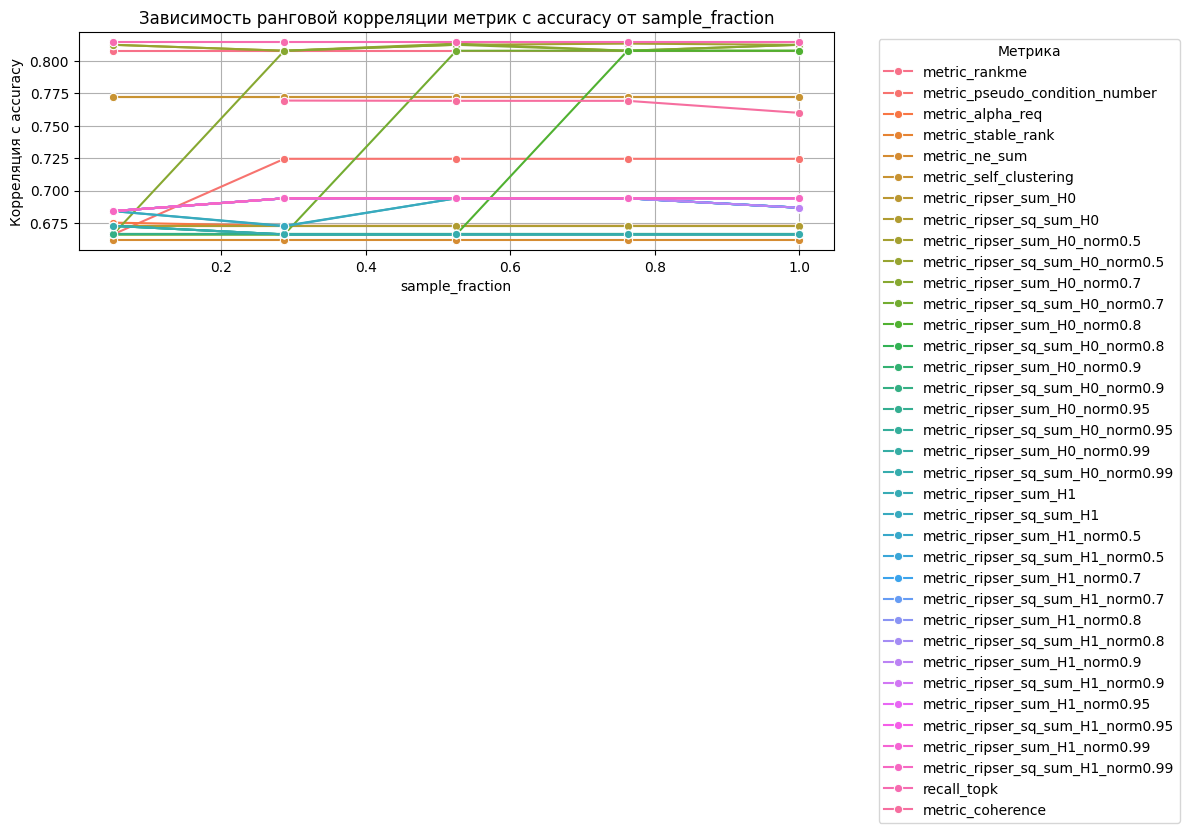

split_count


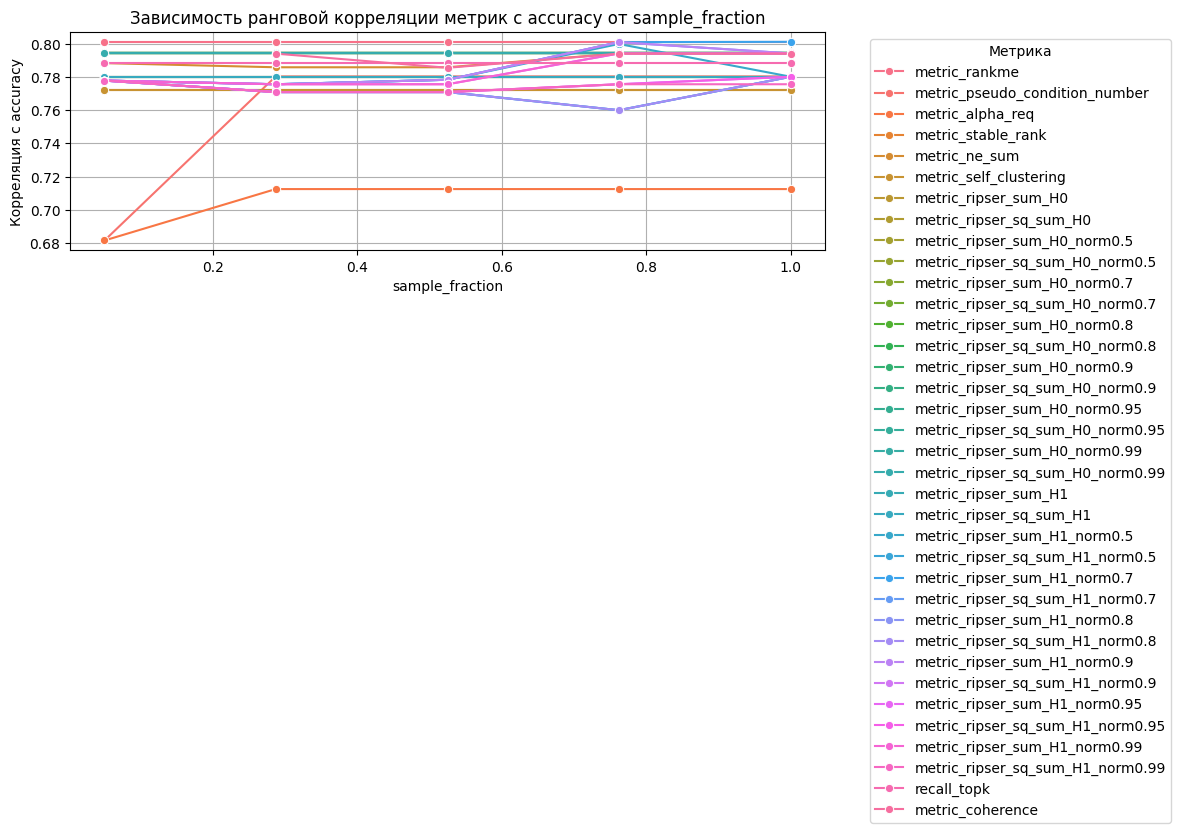

cnt_min


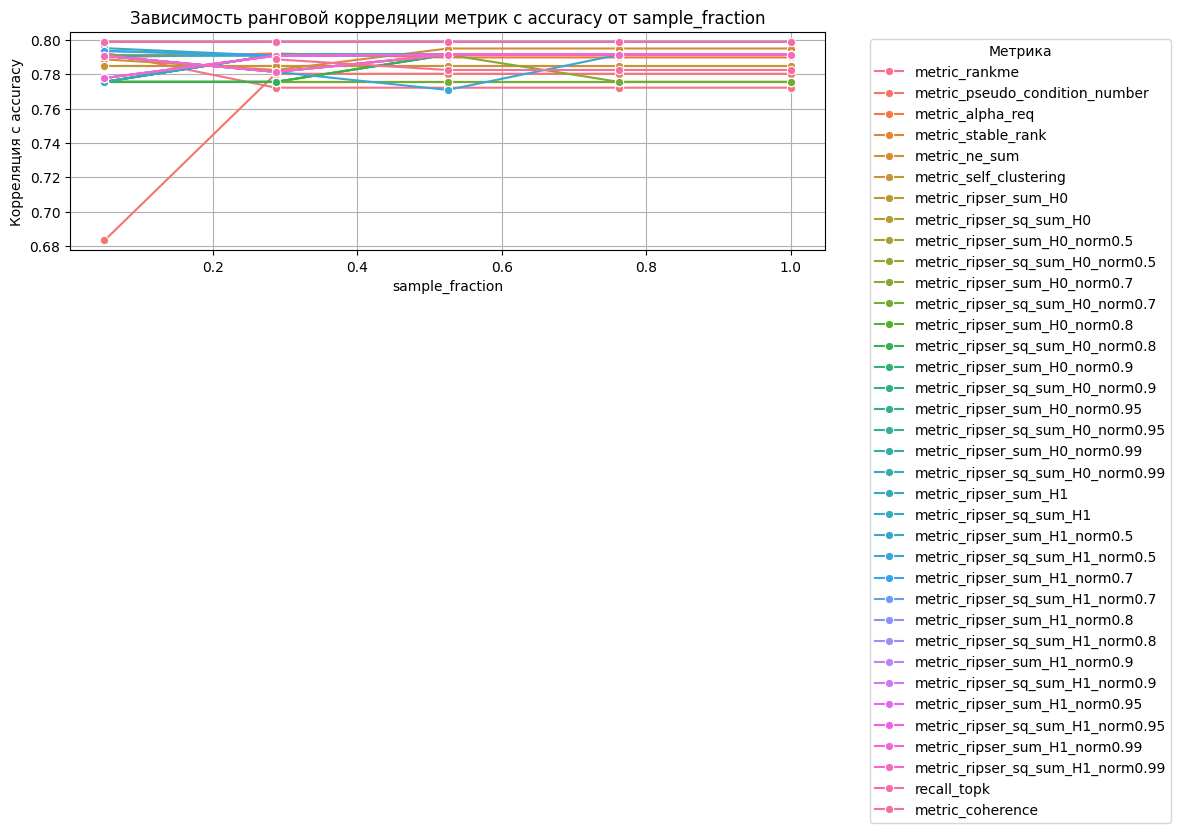

cnt_max


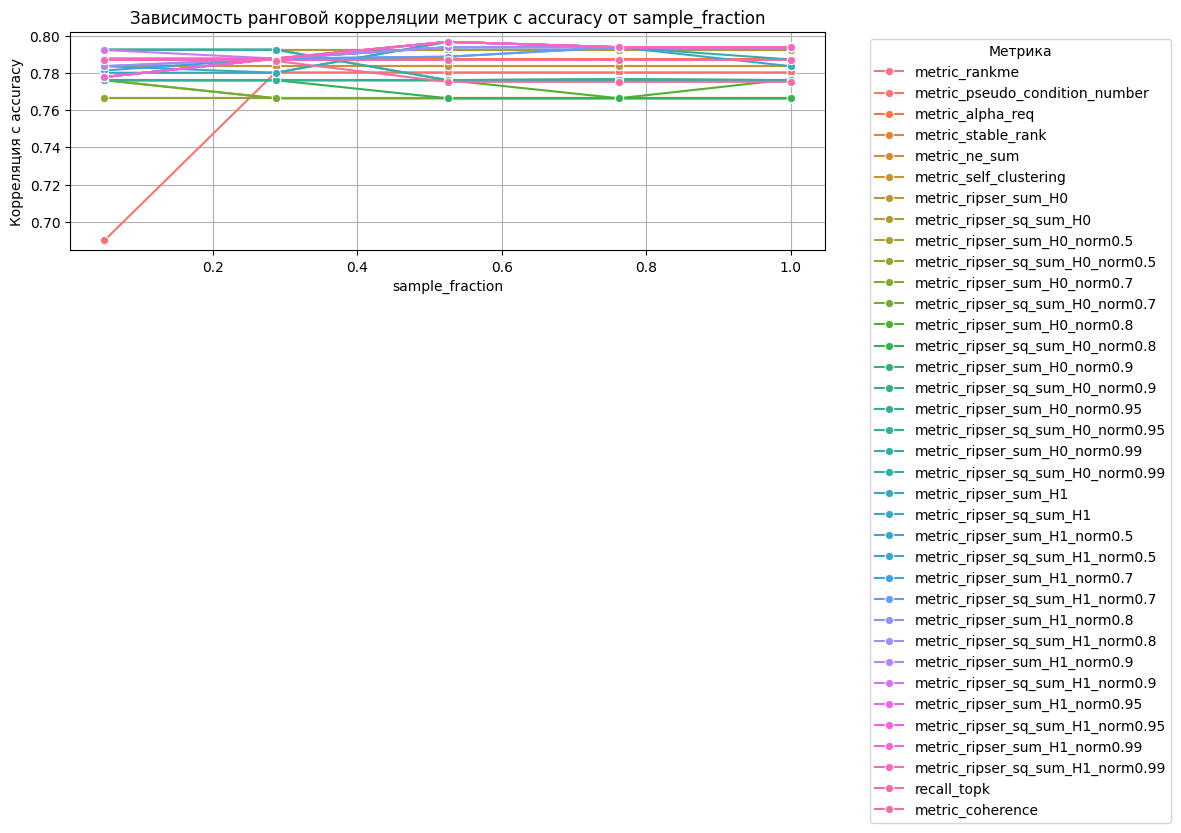

embedding_dim


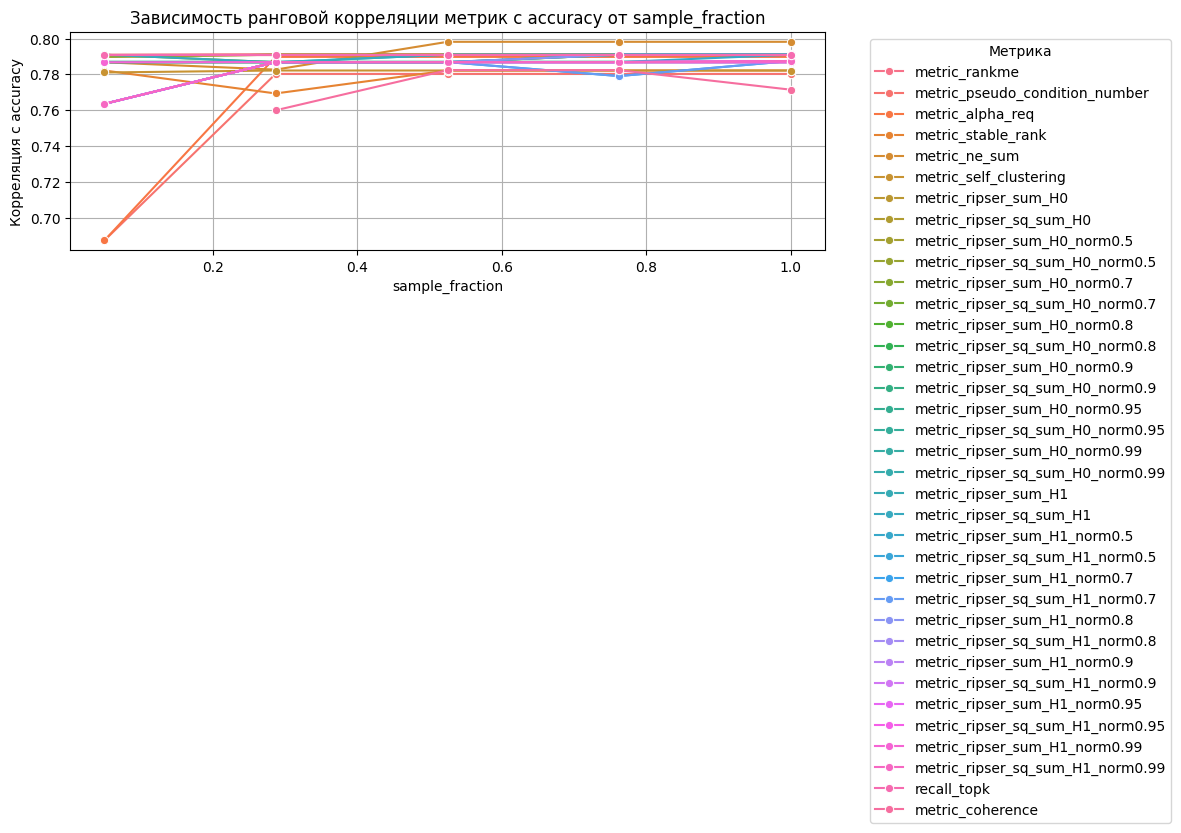

category_embedding_dim


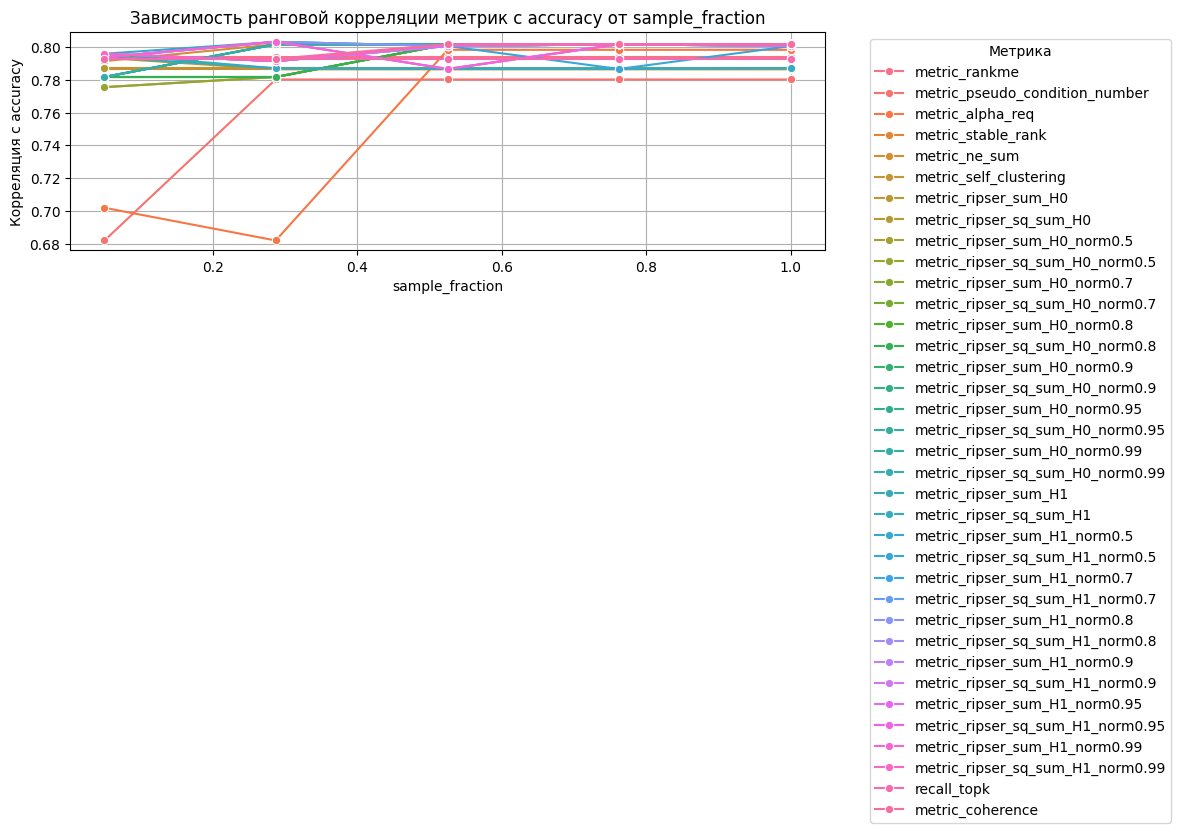

hidden_size


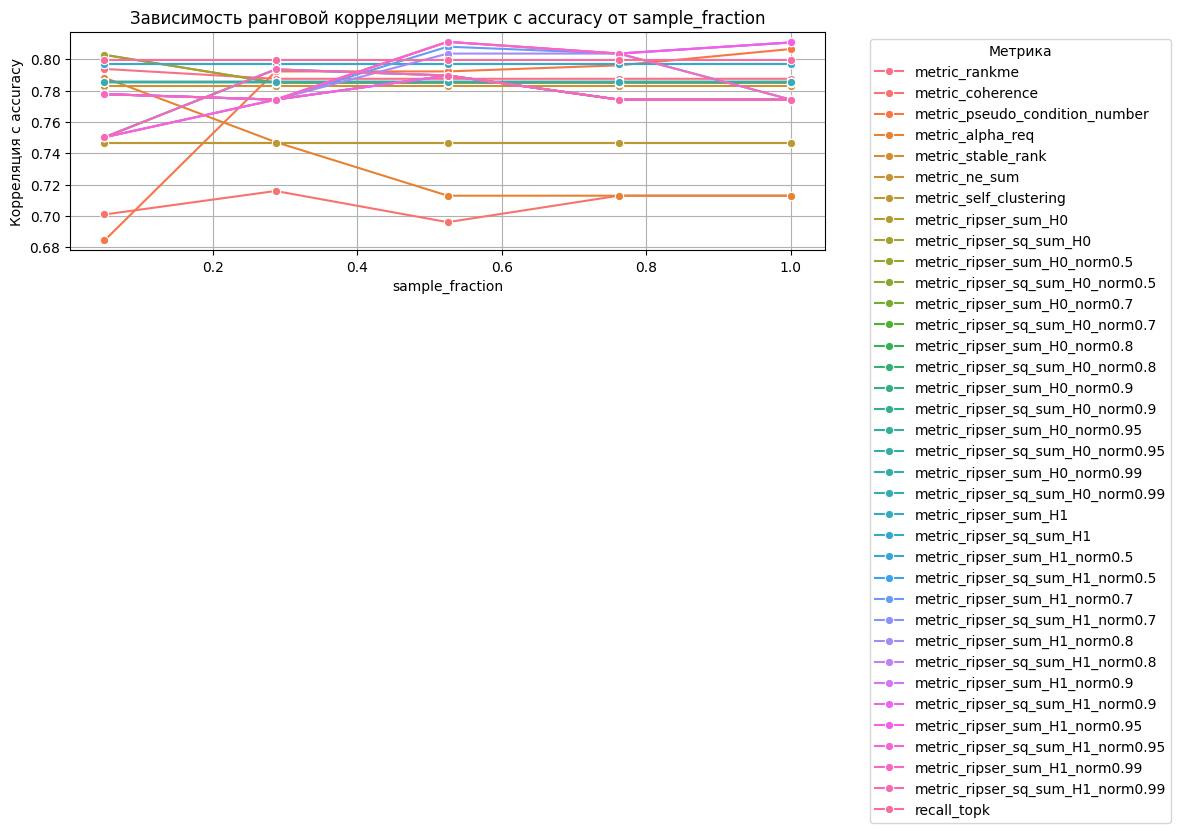

loss


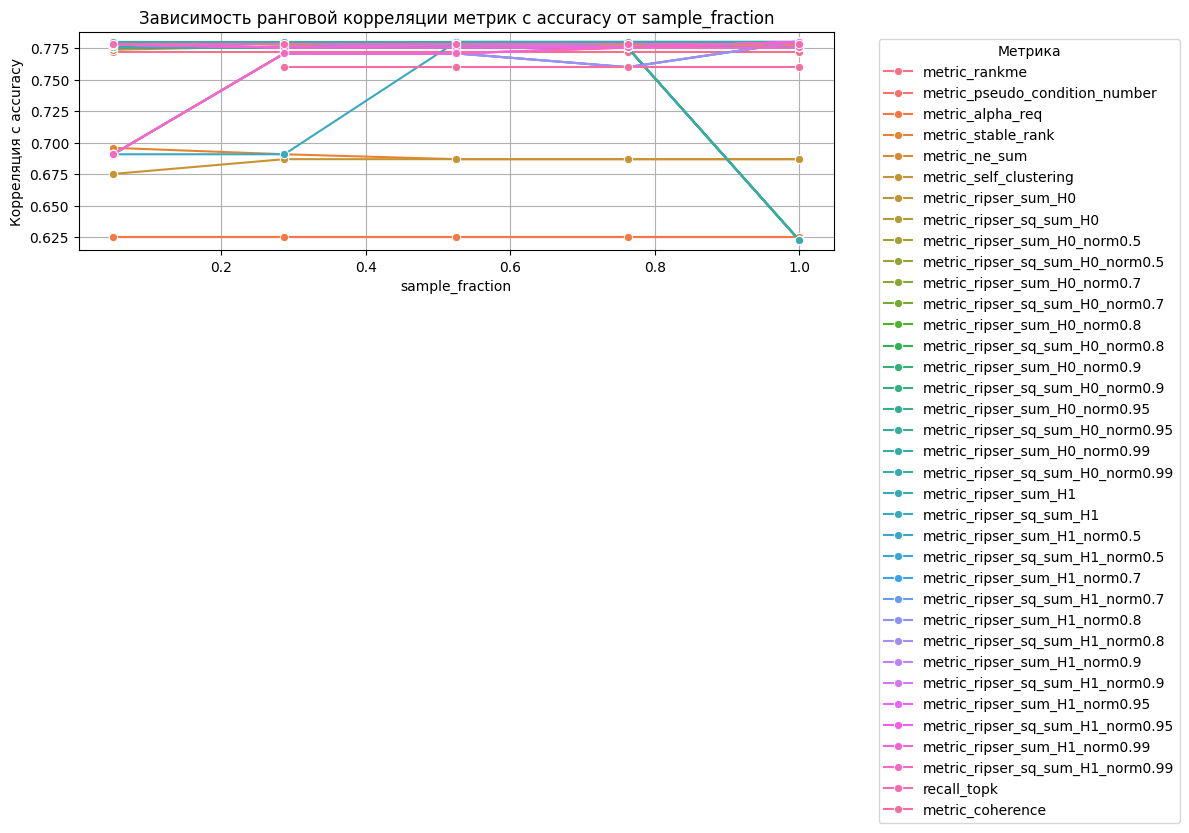

rnn_encoder_type


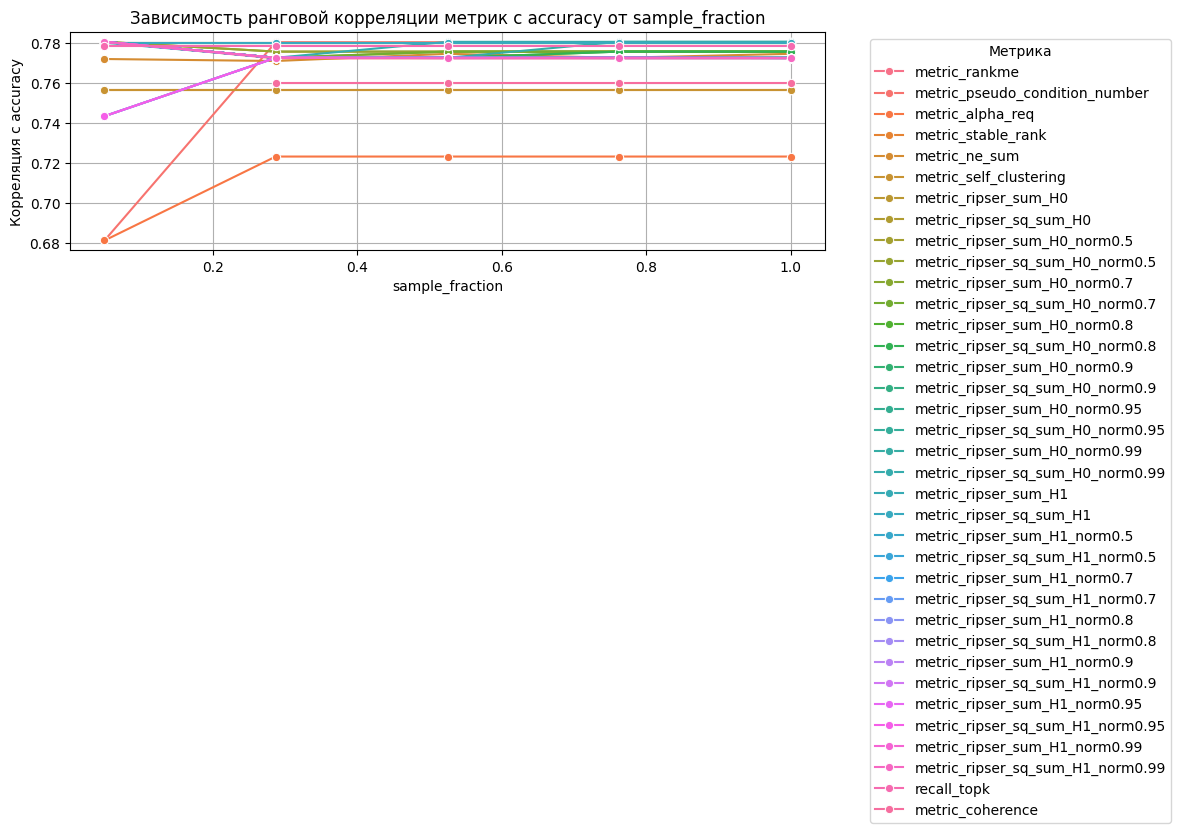

In [40]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    print(param)
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=corr_df, x="sample_fraction", y="auc", hue="metric", marker="o")
    plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
    plt.xlabel("sample_fraction")
    plt.ylabel("Корреляция с accuracy")
    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
    plt.tight_layout()
    plt.show()
    

In [44]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    print(param)
    print (corr_df)
    if corr_df.shape[0]:
        mean_corr = corr_df[corr_df['sample_fraction'] < 0.2].groupby("metric")["auc"].mean().sort_values(ascending=False)
    
        print(mean_corr)

batch_size
     sample_fraction                            metric     auc
0               0.05                     metric_rankme  0.7806
1               0.05    metric_pseudo_condition_number  0.7504
2               0.05                  metric_alpha_req  0.7759
3               0.05                metric_stable_rank  0.7989
4               0.05                     metric_ne_sum  0.7738
..               ...                               ...     ...
174             1.00     metric_ripser_sum_H1_norm0.95  0.7801
175             1.00  metric_ripser_sq_sum_H1_norm0.95  0.7932
176             1.00     metric_ripser_sum_H1_norm0.99  0.7756
177             1.00  metric_ripser_sq_sum_H1_norm0.99  0.7932
178             1.00                       recall_topk  0.7989

[179 rows x 3 columns]
metric
recall_topk                         0.7989
metric_stable_rank                  0.7989
metric_self_clustering              0.7989
metric_ripser_sum_H1                0.7863
metric_ripser_sq_sum_H1       

In [42]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    print(param)
    if corr_df.shape[0]:
        mean_corr = corr_df[corr_df['sample_fraction'] > 0.8].groupby("metric")["auc"].mean().sort_values(ascending=False)

        print(mean_corr)

batch_size
metric
metric_alpha_req                    0.8007
recall_topk                         0.7989
metric_stable_rank                  0.7989
metric_self_clustering              0.7989
metric_ripser_sum_H1                0.7932
metric_ripser_sq_sum_H1             0.7932
metric_ripser_sq_sum_H1_norm0.95    0.7932
metric_ripser_sq_sum_H1_norm0.9     0.7932
metric_ripser_sq_sum_H1_norm0.7     0.7932
metric_ripser_sq_sum_H1_norm0.8     0.7932
metric_ripser_sq_sum_H1_norm0.99    0.7932
metric_ripser_sq_sum_H0             0.7855
metric_ripser_sum_H0                0.7855
metric_ripser_sum_H1_norm0.8        0.7801
metric_ripser_sum_H1_norm0.5        0.7801
metric_ripser_sum_H1_norm0.9        0.7801
metric_ripser_sum_H1_norm0.95       0.7801
metric_ripser_sum_H1_norm0.7        0.7801
metric_rankme                       0.7796
metric_ne_sum                       0.7766
metric_ripser_sum_H0_norm0.7        0.7756
metric_ripser_sum_H0_norm0.99       0.7756
metric_ripser_sq_sum_H0_norm0.5     

In [28]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    if (corr_df.shape[0]):
        mean_corr = corr_df[corr_df['sample_fraction'] > 0.0].groupby("metric")["auc"].mean().sort_values(ascending=False)
        print(param)
        print(mean_corr)

batch_size
metric
recall_topk                         0.76280
metric_ne_sum                       0.74464
metric_ripser_sq_sum_H1_norm0.99    0.74334
metric_ripser_sq_sum_H1_norm0.95    0.73962
metric_alpha_req                    0.73534
metric_ripser_sq_sum_H1_norm0.9     0.73506
metric_rankme                       0.73290
metric_coherence                    0.72920
metric_ripser_sq_sum_H0_norm0.5     0.72830
metric_ripser_sum_H0_norm0.5        0.72668
metric_ripser_sq_sum_H0_norm0.7     0.72416
metric_ripser_sum_H0_norm0.7        0.71910
metric_ripser_sum_H0_norm0.99       0.71732
metric_ripser_sq_sum_H0_norm0.8     0.71658
metric_ripser_sq_sum_H0_norm0.99    0.71490
metric_ripser_sum_H0_norm0.95       0.71462
metric_ripser_sq_sum_H0_norm0.95    0.71462
metric_ripser_sum_H0_norm0.8        0.71442
metric_ripser_sq_sum_H0_norm0.9     0.71442
metric_pseudo_condition_number      0.70996
metric_self_clustering              0.70880
metric_stable_rank                  0.70880
metric_ripser_

In [74]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    mean_corr = corr_df[corr_df['sample_fraction'] > 0.0].groupby("metric")["auc"].mean().sort_values(ascending=False)
    print(param)
    print(mean_corr)

batch_size
metric
metric_ripser_sum_H0              0.751540
ripser_weighted                   0.744400
metric_ripser_sum                 0.740300
metric_ripser_sum_H1              0.729160
metric_alpha_req                  0.722520
metric_pseudo_condition_number    0.722320
metric_stable_rank                0.719900
metric_self_clustering            0.719900
recall_topk                       0.719900
metric_coherence                  0.711575
metric_rankme                     0.709220
metric_ne_sum                     0.705820
Name: auc, dtype: float64
learning_rate
metric
metric_ne_sum                     0.73350
recall_topk                       0.72450
metric_coherence                  0.70770
metric_rankme                     0.70210
ripser_weighted                   0.65940
metric_ripser_sum_H1              0.65940
metric_alpha_req                  0.63348
metric_ripser_sum_H0              0.58778
metric_ripser_sum                 0.58778
metric_pseudo_condition_number    0.53640

# Standard deviation of score of best param selection

In [43]:
std_corr = {}
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    std_corr[param] = corr_df.groupby("metric")["auc"].std().sort_values()

/tmp/ipykernel_3412665/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_3412665/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


batch_size


/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


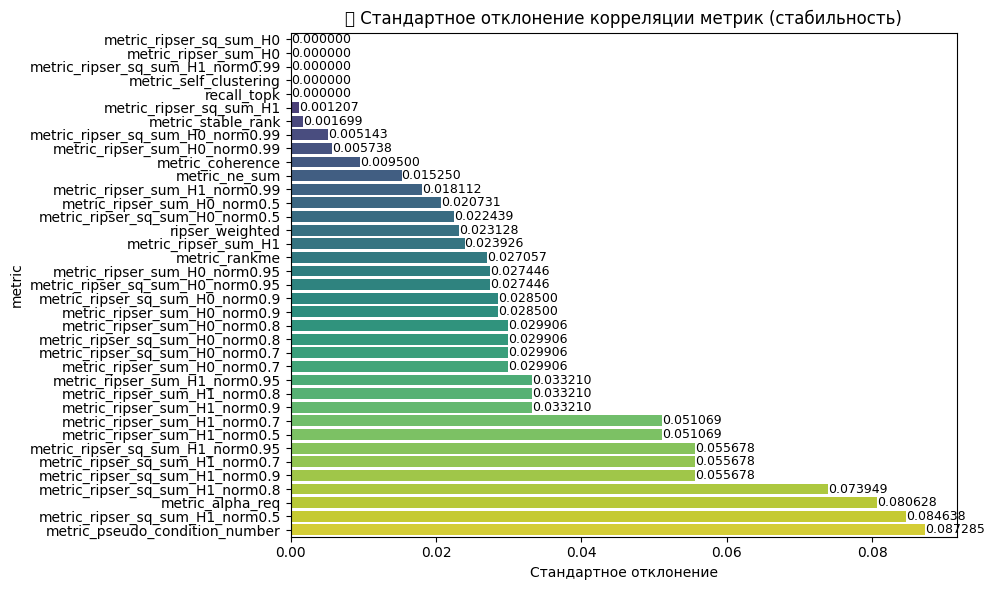

/tmp/ipykernel_3412665/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_3412665/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


learning_rate


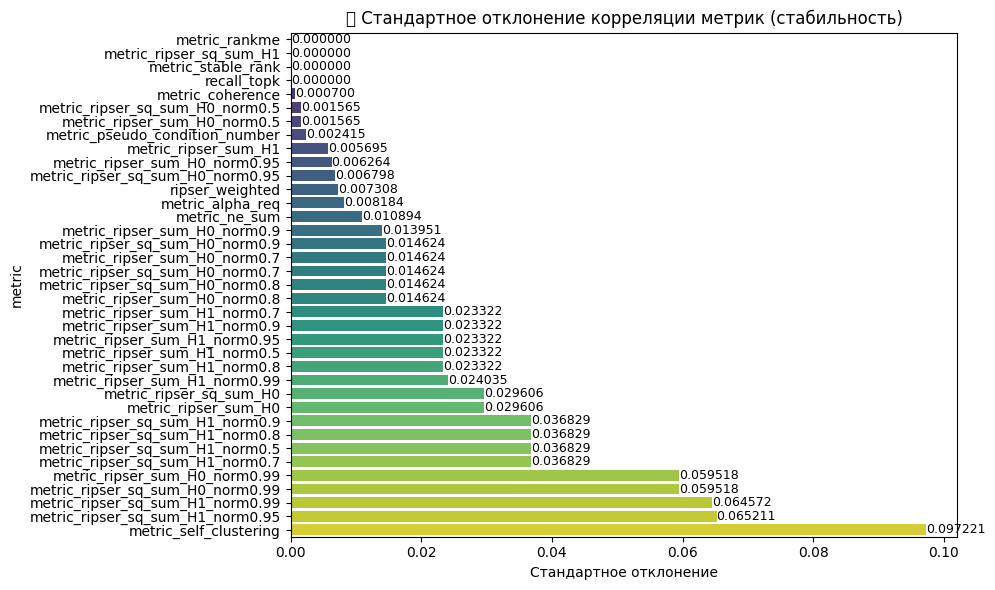

/tmp/ipykernel_3412665/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")


split_count


/tmp/ipykernel_3412665/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


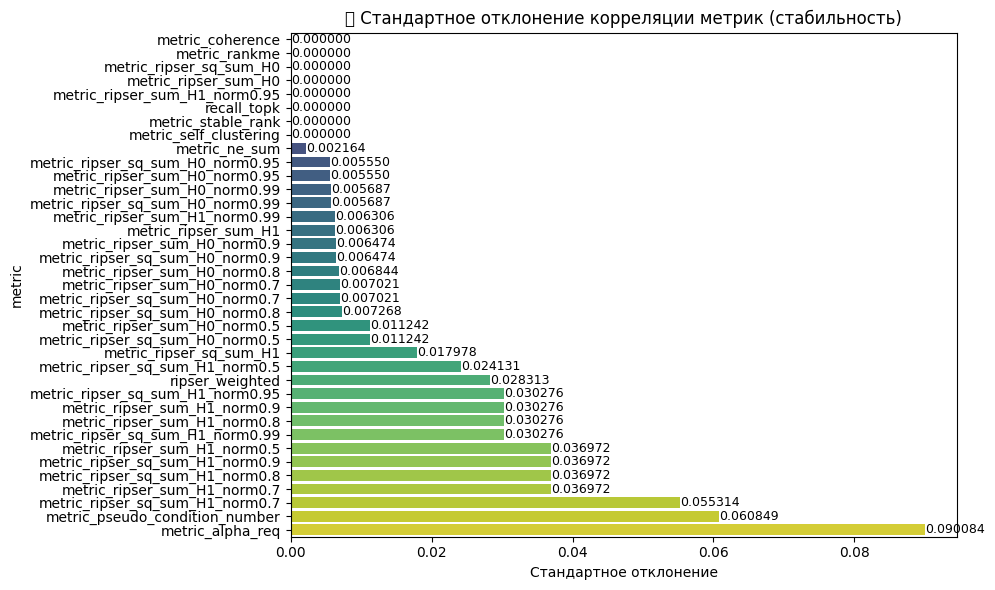

/tmp/ipykernel_3412665/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_3412665/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


cnt_min


/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


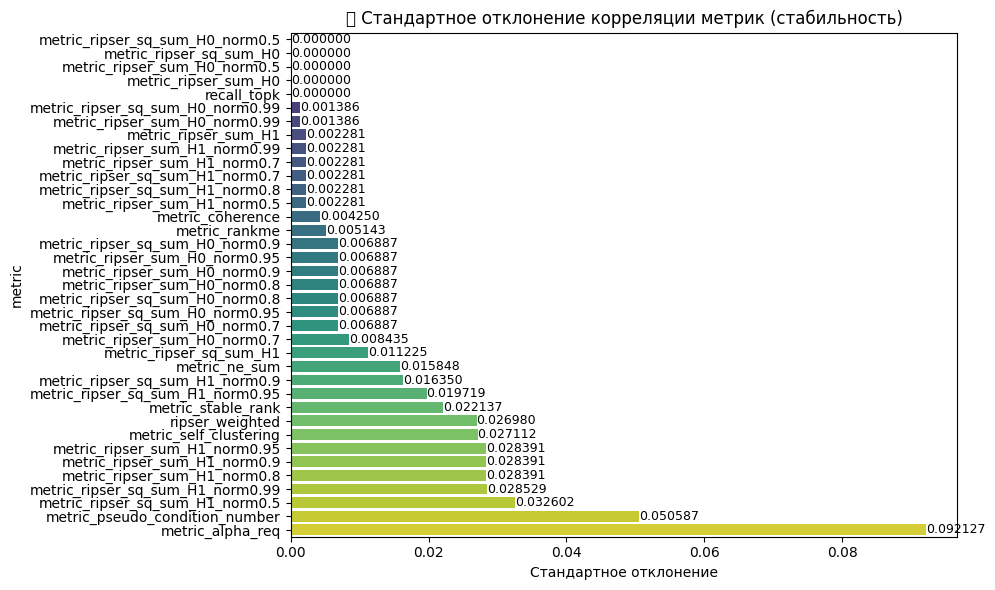

/tmp/ipykernel_3412665/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_3412665/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


cnt_max


/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


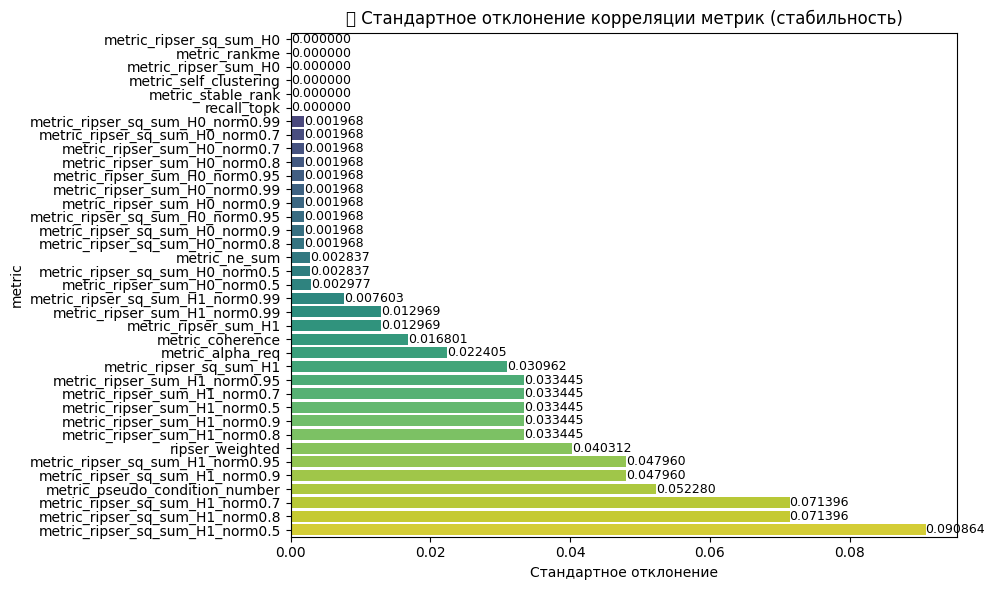

/tmp/ipykernel_3412665/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_3412665/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


embedding_dim


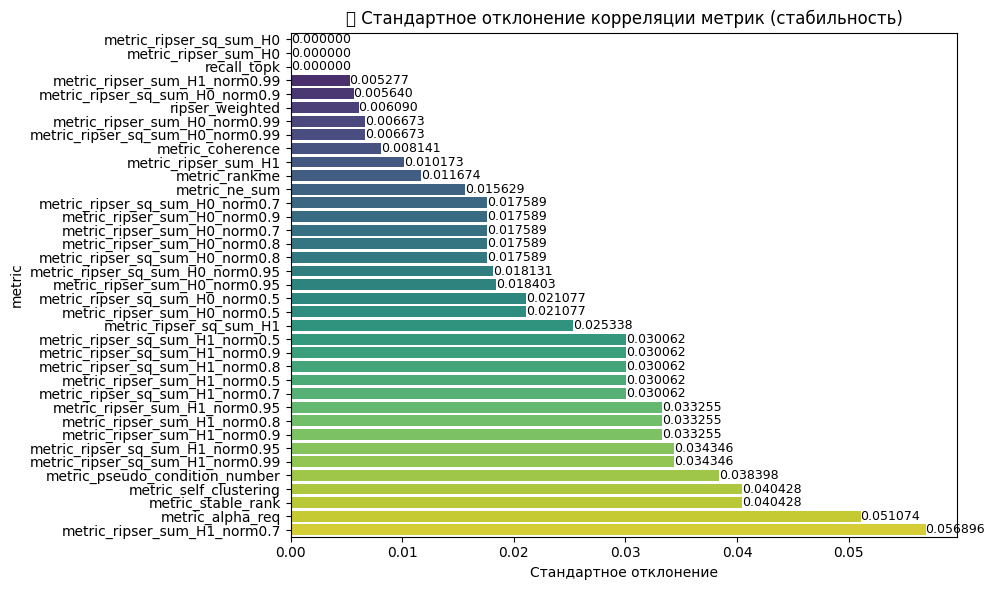

/tmp/ipykernel_3412665/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_3412665/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


category_embedding_dim


/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


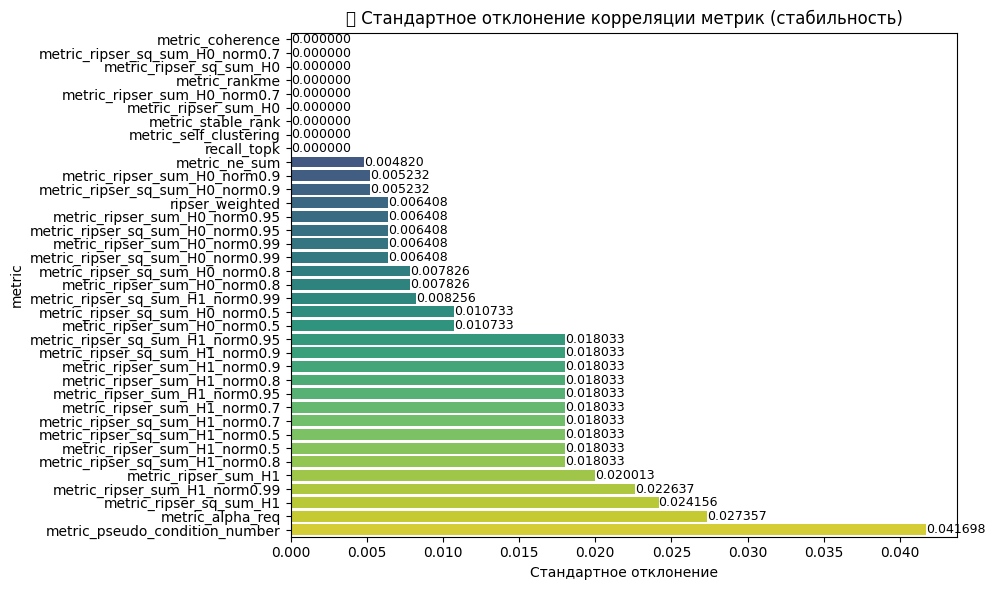

/tmp/ipykernel_3412665/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_3412665/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


hidden_size


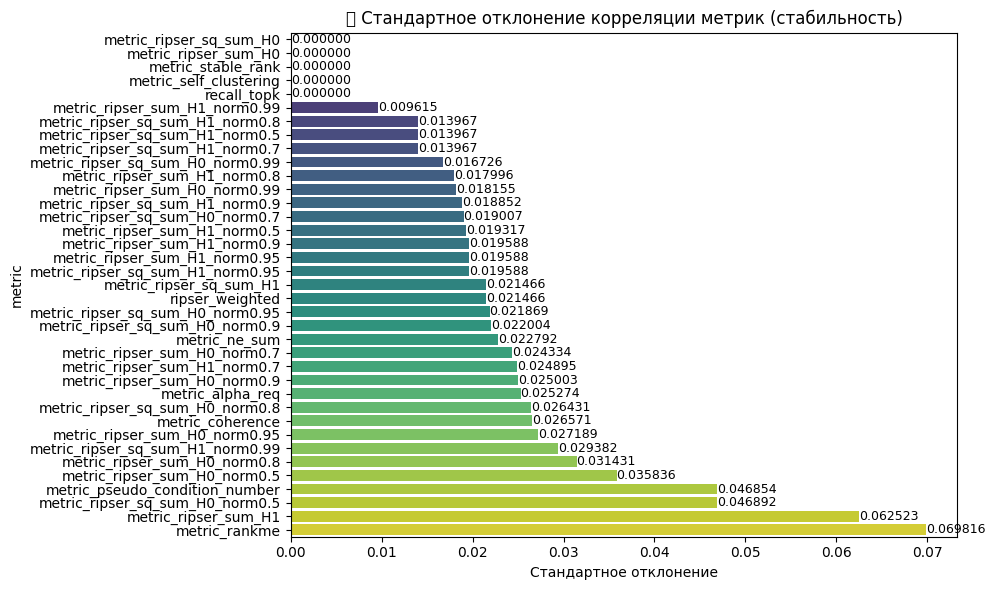

In [45]:
for param in params_cols:
    sorted_std = std_corr[param].sort_values(ascending=True)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
    
    for i, v in enumerate(sorted_std.values):
        plt.text(v, i, f"{v:.6f}", color='black', ha='left', va='center', fontsize=9)
    print(param)
    plt.title("📉 Стандартное отклонение корреляции метрик (стабильность)")
    plt.xlabel("Стандартное отклонение")
    plt.tight_layout()
    plt.show()